# MoLA Training Tutorial

Train a model on the simple and small fraction-subtraction dataset.

In [2]:
%load_ext autoreload
%autoreload 2

## Step 1: Download the Fraction-Subtraction Dataset

In [3]:
import pyreadr
import requests
import tempfile

# Helper function to retrieve data from Github
def download_R_file_to_pandas(file_name):

    # Path to datasets in Github CDM repo
    path = "https://raw.githubusercontent.com/cran/CDM/master/data/"
    response = requests.get(path + file_name + ".rda")
    response.raise_for_status()

    # Write .RDA file to temp and load using pyreadr
    with tempfile.NamedTemporaryFile(suffix=".rda", delete=True) as f:
        f.write(response.content)
        f.flush()

        result = pyreadr.read_r(f.name)

    # Fetch pandas dataframe
    df = result[file_name]
    return df

### Step 1a: Download Item-Response Data Matrix
`X`: binary user-item matrix, where a "1" signifies a correct response and a "0" signifies an incorrect response.

In [4]:
# Download the data
df = download_R_file_to_pandas("fraction.subtraction.data")

# Convert to NumPy array
X = df.to_numpy()  

# Print shape and header
print("Item response data shape:", df.shape)
df.head()

Item response data shape: (536, 20)


,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8,Item9,Item10,Item11,Item12,Item13,Item14,Item15,Item16,Item17,Item18,Item19,Item20
0,0,0,0,1,0,0,1,1,0,1,1,1,0,1,1,1,0,1,1,1
1,0,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
2,0,1,1,1,0,1,1,1,0,0,0,0,0,1,1,1,0,0,0,0
3,1,1,1,1,1,1,0,1,0,1,1,1,0,1,0,1,0,1,0,1
4,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0


### Step 1b: Download the Q-matrix

`Q_matrix`: binary item-skill matrix, where a "1" signifies that the item requires the skill, and "0" signifies the opposite.

In [5]:
df = download_R_file_to_pandas("fraction.subtraction.qmatrix")

# Convert to NumPy array
Q_matrix = df.to_numpy()

# Print shape and header
print("Item response data shape:", df.shape)
df.head()

Item response data shape: (20, 8)


,alpha1,alpha2,alpha3,alpha4,alpha5,alpha6,alpha7,alpha8
rownames,,,,,,,,
Item1,0,0,0,1,0,1,1,0
Item2,0,0,0,1,0,0,1,0
Item3,0,0,0,1,0,0,1,0
Item4,0,1,1,0,1,0,1,0
Item5,0,1,0,1,0,0,1,1


## Step 2: Configure and Train the Model

## Stress Test Experiment
Fit a model with way too many components.

In [5]:
from aplus.cognitive_model import MoLA

# Configure model parameters
model_params = {
    'Q_matrix': Q_matrix,
    'n_components': 10,
    'mu_smooth': [2, 2],
    'theta_smooth': [2, 2],
    'pi_smooth': 1,
    'tol': 1e-5,
    'n_iter': 50,
    'use_psuedo_likelihood': False
}

# Instantiate the model
model_small = MoLA(**model_params)

# Fit the model to the data
model_small.fit(X)

In [7]:
# Fit a second MoLA model with a small number of params
# Configure model parameters
model_params = {
    'Q_matrix': Q_matrix,
    'n_components': 16,
    'mu_smooth': [2, 2],
    'theta_smooth': [2, 2],
    'pi_smooth': 1,
    'tol': 1e-5,
    'n_iter': 50,
}

# Instantiate the model
model_large = MoLA(**model_params)

# Fit the model to the data
model_large.fit(X)

In [99]:
# Fit a second MoLA model with a small number of params
# Configure model parameters
model_params = {
    'Q_matrix': Q_matrix,
    'n_components': 100,
    'mu_smooth': [2, 2],
    'theta_smooth': [2, 2],
    'pi_smooth': 1,
    'tol': 1e-5,
    'n_iter': 50,
}

# Instantiate the model
model_largest = MoLA(**model_params)

# Fit the model to the data
model_largest.fit(X)

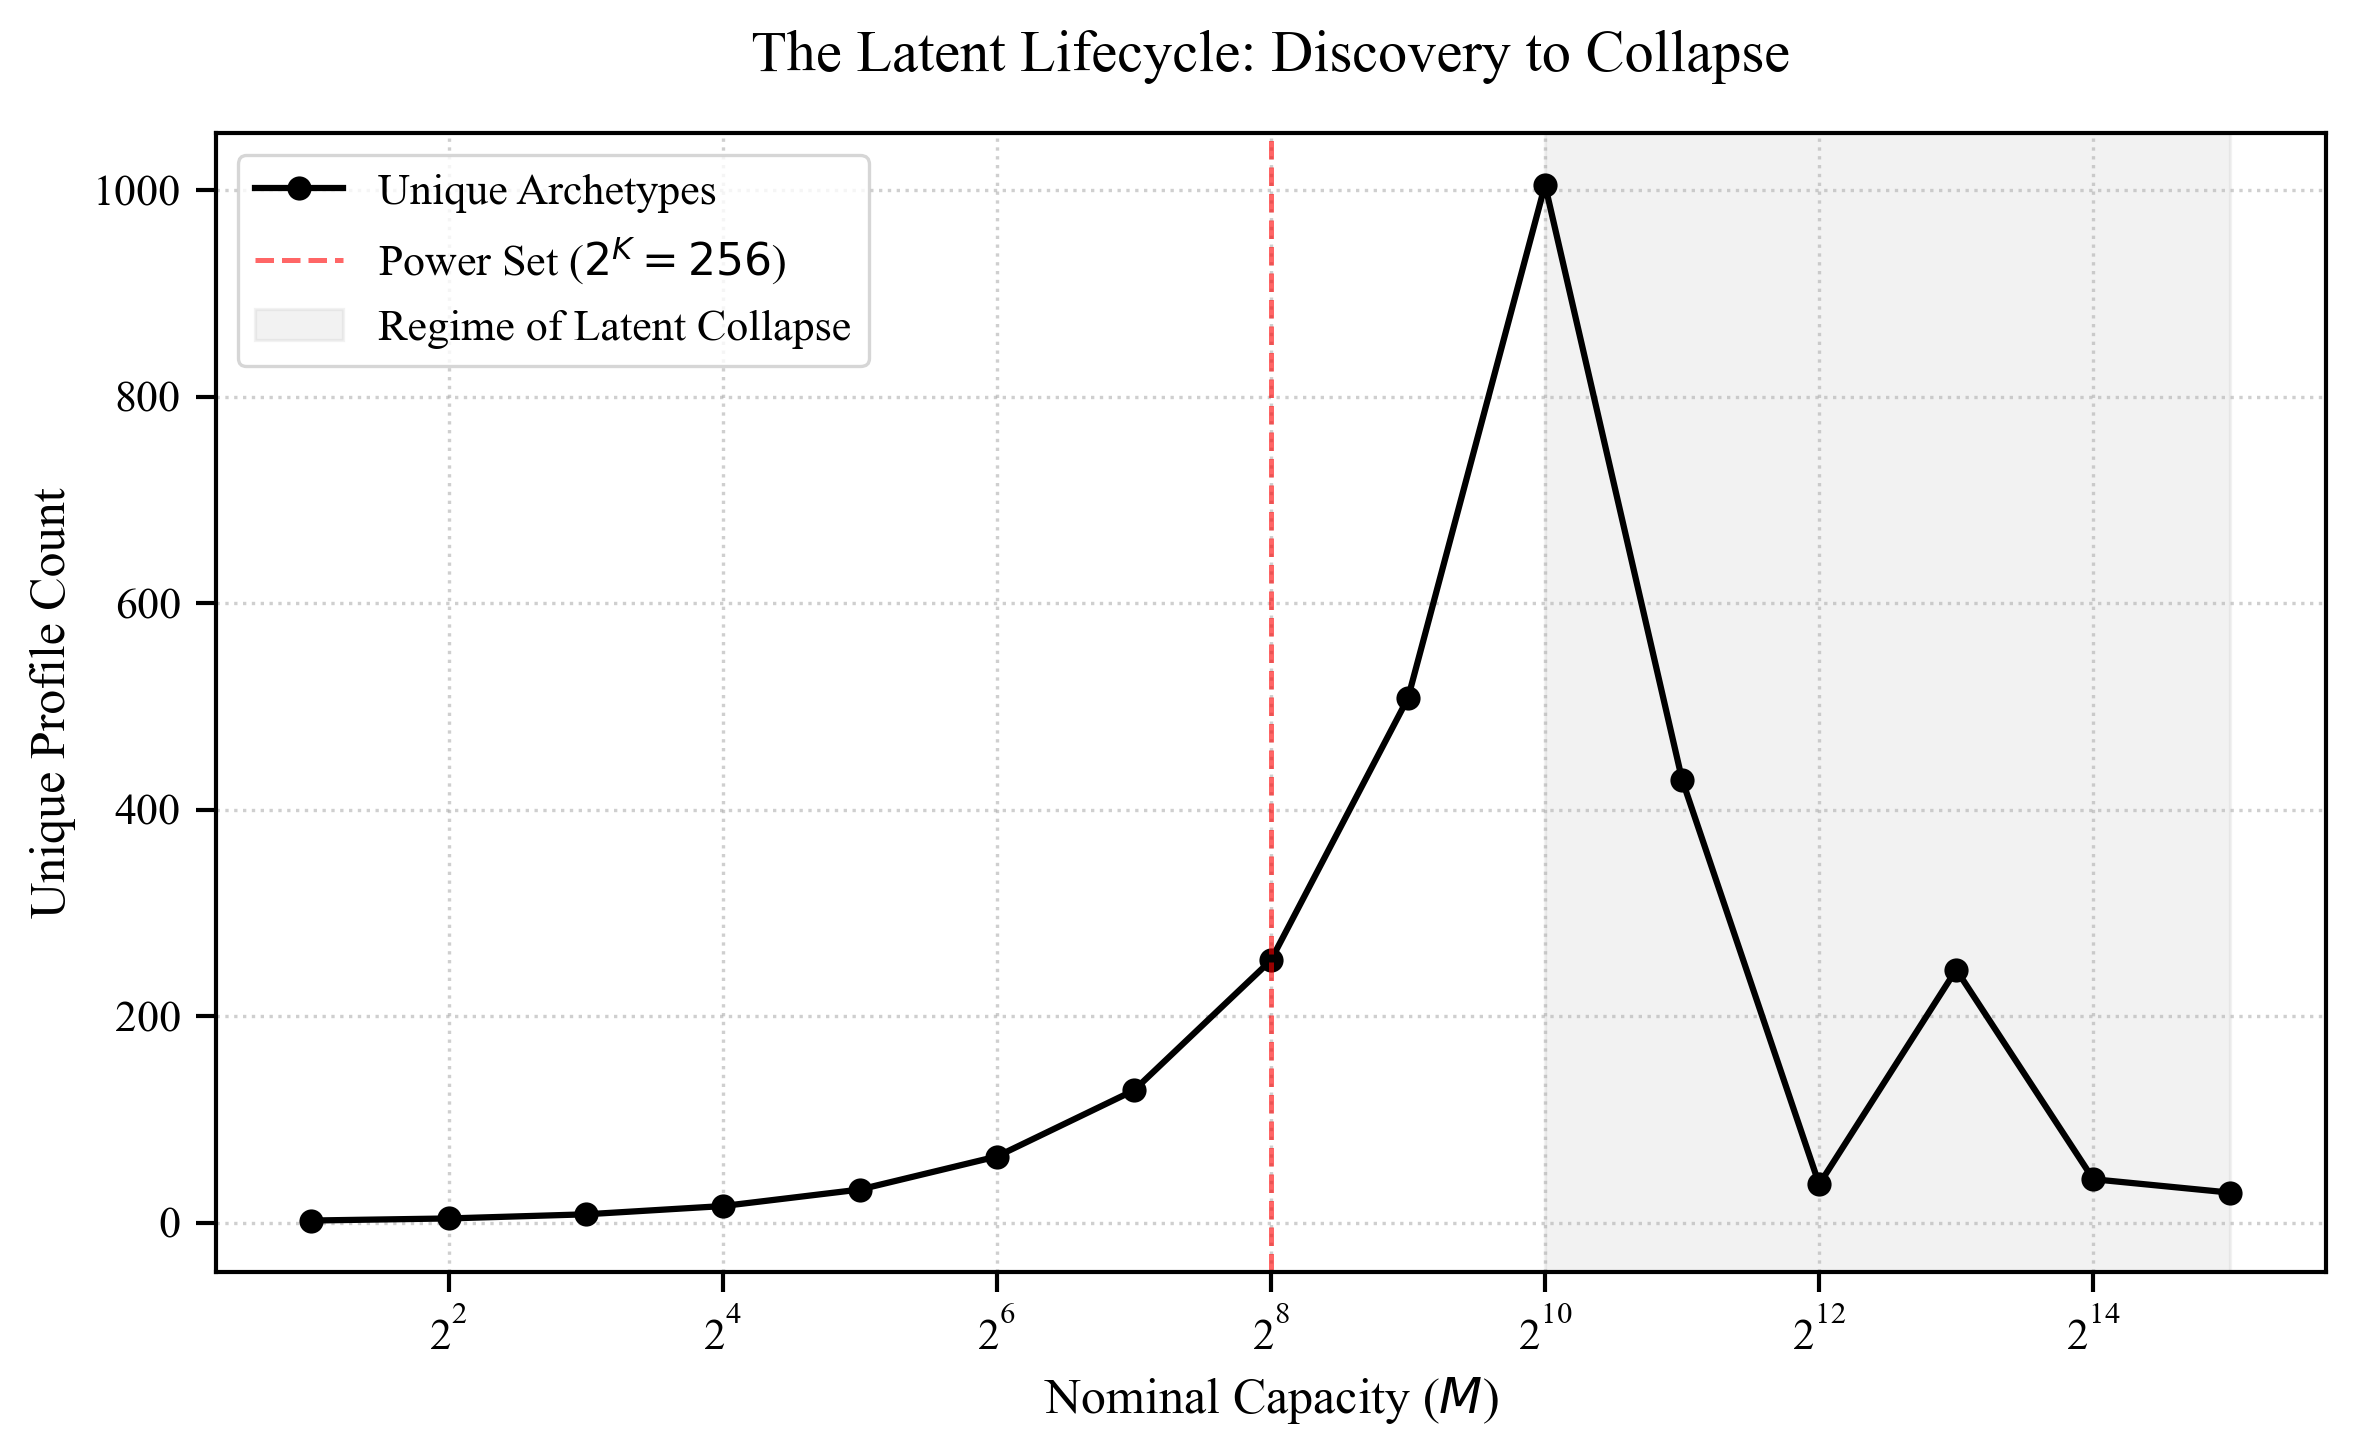

In [136]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# 1. Config
rcParams.update({"font.family": "serif", "font.serif": ["Times New Roman"], "figure.dpi": 300})

m_values = [2**k for k in range(1, 16, 1)]
# comp_counts = [2, 4, 8, 16, 32, 64, 128, 254, 508, 1005, 429, 37, 245, 42, 29]

fig, ax = plt.subplots(figsize=(8, 5))

# 2. Plotting the Lifecycle
ax.plot(m_values, comp_counts, 'o-', color='black', linewidth=1.5, label='Unique Archetypes')

# 3. Reference Lines
ax.axvline(256, color='red', linestyle='--', alpha=0.6, label='Power Set ($2^K=256$)')
ax.axvspan(1024, m_values[-1], color='gray', alpha=0.1, label='Regime of Latent Collapse')

# 4. Styling
ax.set_xscale('log', base=2)
ax.set_xlabel("Nominal Capacity ($M$)", fontsize=12)
ax.set_ylabel("Unique Profile Count", fontsize=12)
ax.set_title("The Latent Lifecycle: Discovery to Collapse", fontsize=14, pad=15)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend()

plt.tight_layout()
plt.show()


<>:81: SyntaxWarning: invalid escape sequence '\m'
<>:81: SyntaxWarning: invalid escape sequence '\m'
/var/folders/vk/bnzg451d24310v57025d6tmw0000gn/T/ipykernel_78550/53406616.py:81: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("Mean Component Proficiency ($\mu_{m \cdot}$)", fontsize=13)
/var/folders/vk/bnzg451d24310v57025d6tmw0000gn/T/ipykernel_78550/53406616.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=df, x='M', y='Proficiency', inner="quart", palette="muted", cut=0)


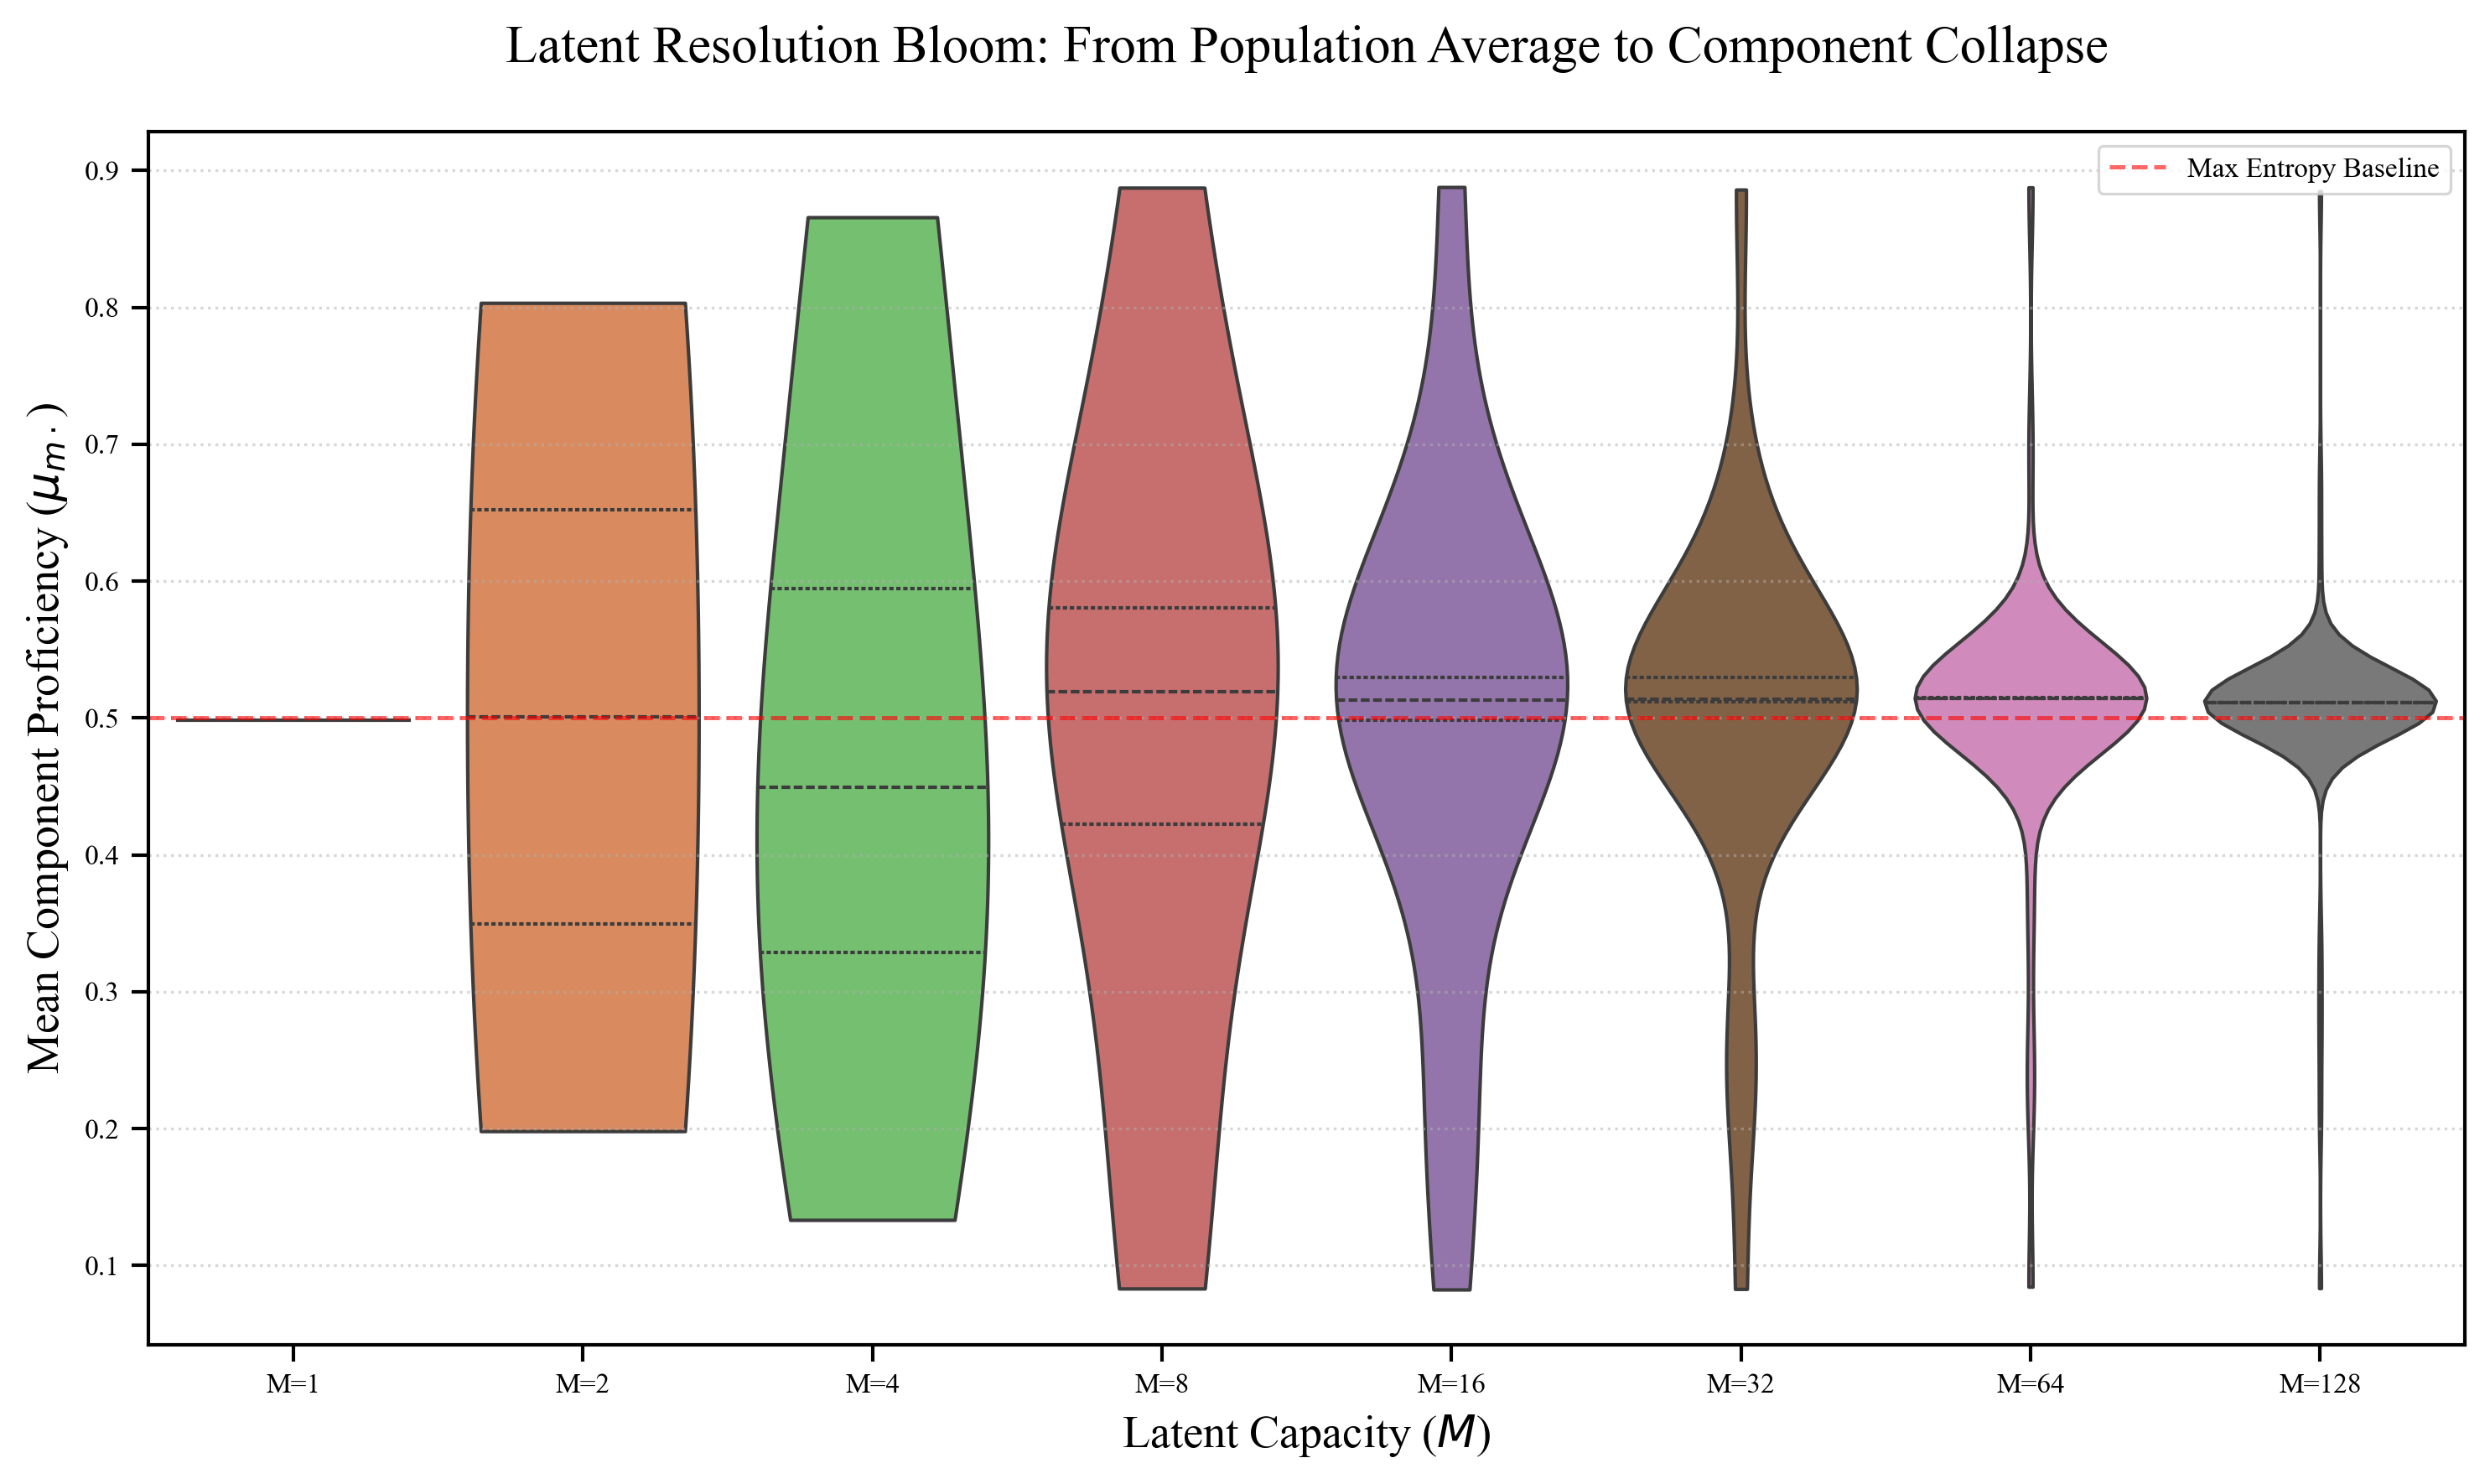

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import rcParams
from sklearn.cluster import DBSCAN


# 1. Publication Config
rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "figure.dpi": 300
})

# Data collection container
all_data = []
# 10
m_values = [2**k for k in range(0, 8, 1)] # e.g., 2, 8, 32, 128, 512
comp_counts = []
for m in m_values:
    # --- Your Model Fitting Logic Here ---
    model_params = {
        'Q_matrix': Q_matrix,
        'n_components': m,
        'mu_smooth': [2, 2],
        'theta_smooth': [2, 2],
        'pi_smooth': 1,
        'tol': 1e-5,
        'n_iter': 50,
    }

    # Instantiate the model
    model = MoLA(**model_params)
    model.fit(X)
    
    # Calculate mean proficiency per component
    means = model.mu.mean(axis=1)
    temp_df = pd.DataFrame({'Proficiency': means})
    temp_df['M'] = f"M={m}"
    all_data.append(temp_df)

    # Refined measurement loop
    # unique_count = model.mu.shape[0] - pd.DataFrame(model.mu).round(4).duplicated().sum()

    # eps is your maximum distance between "similar" rows
    # min_samples=1 ensures every row gets a cluster ID
    clusters = DBSCAN(eps=1e-3, min_samples=1).fit_predict(model.mu)

    # Unique count is the number of unique cluster IDs
    unique_count = len(set(clusters))

    # Functional Idling: How many components are "stuck" at the 0.5 baseline?
    # We use .all(axis=1) because an informative component must deviate from 0.5 
    # on at least one attribute.
    is_neutral = ((model.mu > 0.49) & (model.mu < 0.51)).all(axis=1)
    idling_count = is_neutral.sum()

    active_count = model.mu.shape[0] - idling_count

    comp_counts.append({
        'M': m,
        'Unique': unique_count,
        'Idling': idling_count,
        'Active': active_count,
        'Idling_Pct': (idling_count / m) * 100
    })

df = pd.concat(all_data)

# 2. Plotting the "Resolution Bloom"
plt.figure(figsize=(10, 6))
# Using a log scale for the Y-axis (density) to see the 0.5 spike vs. the wings
ax = sns.violinplot(data=df, x='M', y='Proficiency', inner="quart", palette="muted", cut=0)

# 3. Add the Entropy Horizon
plt.axhline(0.5, color='red', linestyle='--', alpha=0.6, label='Max Entropy Baseline')

# 4. Styling
plt.title("Latent Resolution Bloom: From Population Average to Component Collapse", fontsize=15, pad=20)
plt.ylabel("Mean Component Proficiency ($\mu_{m \cdot}$)", fontsize=13)
plt.xlabel("Latent Capacity ($M$)", fontsize=13)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


In [204]:
((model.mu < 0.51).all(axis=1) | (model.mu > 0.49).all(axis=1)).sum() / model.mu.shape[0]

np.float64(0.999969482421875)

In [31]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# import numpy as np
# from matplotlib import rcParams

# # We make it taller (9 inches) to accommodate the 3-panel stack
# col_width = 3.5 
# fig_height = 2

# rcParams.update({
#     "font.family": "serif",
#     "font.serif": ["Times New Roman"],
#     "font.size": 10,          # Base font size
#     "axes.titlesize": 10,     # Title size
#     "axes.labelsize": 9,      # Axis labels
#     "xtick.labelsize": 8,     # Tick labels
#     "ytick.labelsize": 8,
#     "legend.fontsize": 8,
#     "figure.dpi": 300
# })

# fig, ax1 = plt.subplots(figsize=(col_width, fig_height))
# plt.subplots_adjust(hspace=0.5) # Increased space for readability

# # --- PANEL 1: THE LATENT LIFECYCLE ---
# m_vals_lifecycle = [2**k for k in range(1, 16, 1)]
# # Replace with your actual comp_counts data
# comp_counts = [2, 4, 8, 16, 32, 64, 128, 254, 508, 1005, 429, 37, 245, 42, 29] 
# ax1.plot(m_vals_lifecycle, comp_counts, 'o-', color='black', linewidth=1.5)
# ax1.axvspan(1024, m_values[-1], color='gray', alpha=0.1, label='Regime of Latent Collapse')
# ax1.axvline(256, color='red', linestyle='--', alpha=0.5, label='Power Set ($2^K$)')
# ax1.set_xscale('log', base=2)
# ax1.set_yscale('log', base=2)
# ax1.set_ylabel("Unique Profile Count")
# ax1.set_title("Latent Lifecycle (Discovery to Collapse)")
# ax1.grid(True, linestyle=':', alpha=0.6)
# ax1.legend(fontsize=8)

# plt.tight_layout()
# plt.savefig("figures/latent_lifecycle.pdf", format='pdf', bbox_inches='tight')
# plt.show()

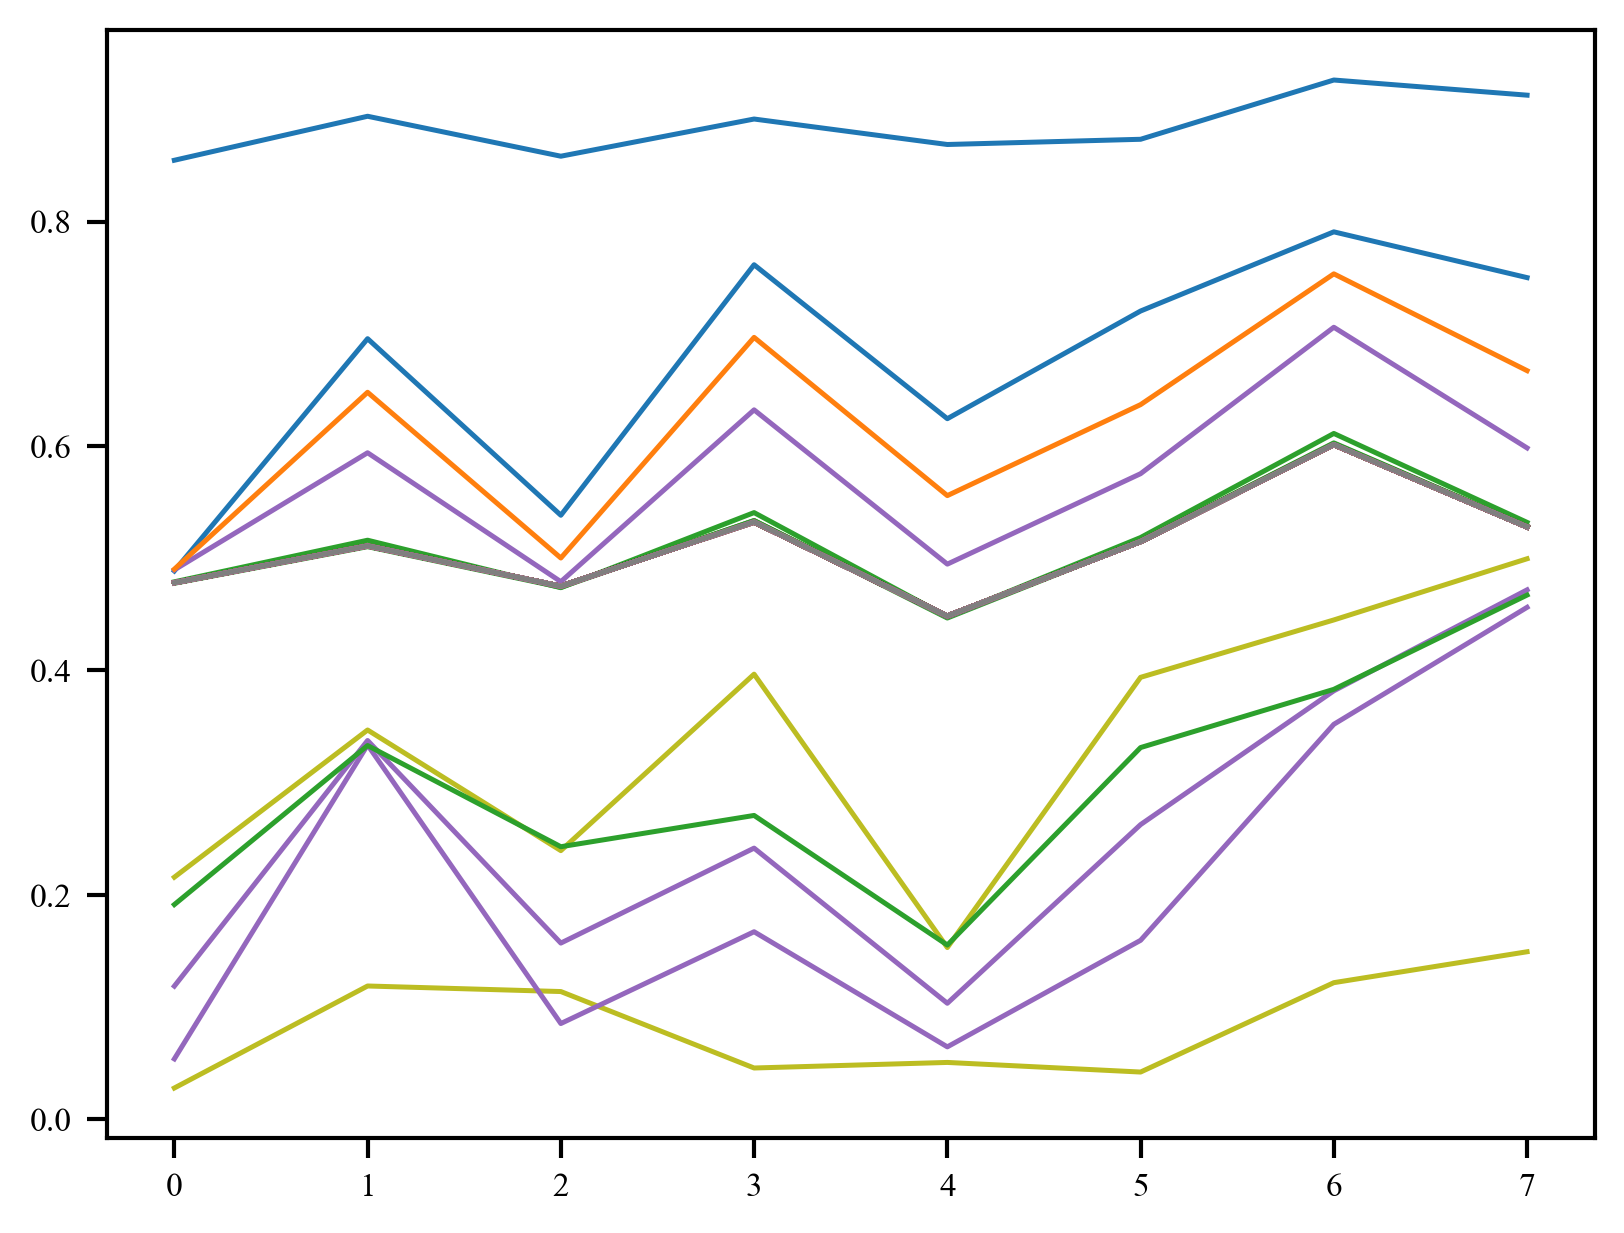

In [35]:
plt.plot(model.mu.T)
plt.show()

In [50]:
sum(model.pi >= 0.01)

array([8])

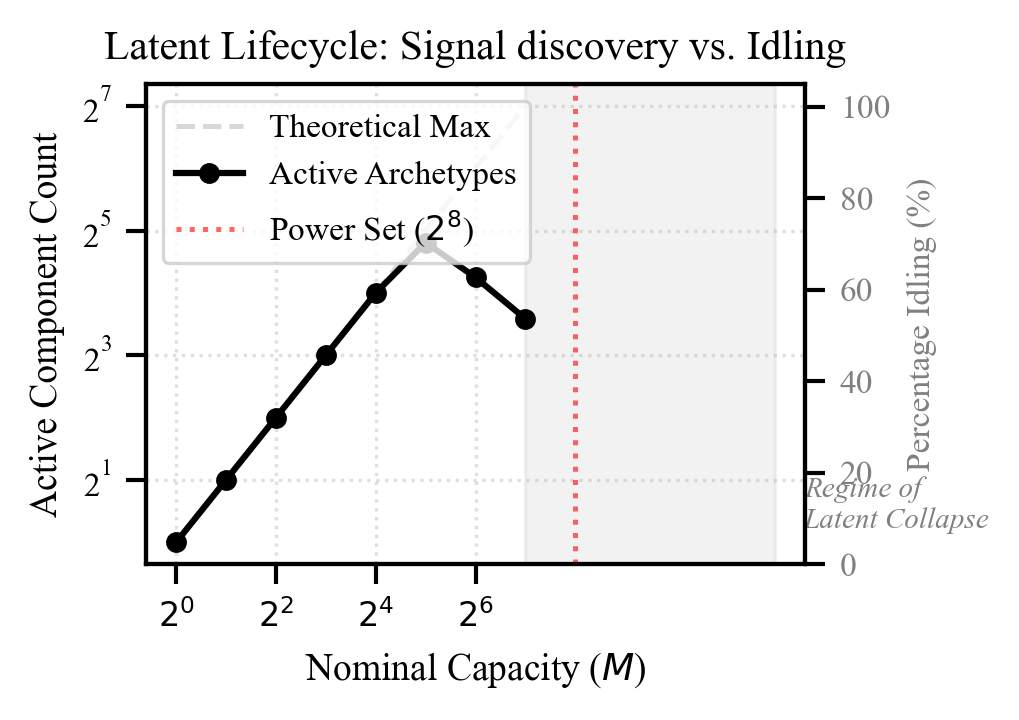

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import rcParams

# Standardize fonts for publication
rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 300
})

# Assuming comp_counts is a list of dicts: [{'M': 2, 'Active': 2}, ...]
# Convert to DataFrame for easy plotting
df_counts = pd.DataFrame(comp_counts)

col_width = 3.5 
fig_height = 2.5 # Slightly taller for legend clarity
fig, ax1 = plt.subplots(figsize=(col_width, fig_height))

# --- Plotting the Active Signal ---
# 1:1 Identity line (where the model would be if it used every component)
ax1.plot(df_counts['M'], df_counts['M'], linestyle='--', color='gray', alpha=0.3, label='Theoretical Max')

# The actual Active Component count
ax1.plot(df_counts['M'], df_counts['Unique'], 'o-', color='black', linewidth=1.5, markersize=4, label='Active Archetypes')

# --- Formatting ---
ax1.set_xscale('log', base=2)
ax1.set_yscale('log', base=2)

# Set X-labels to LaTeX 2^k format
unique_m = df_counts['M'].unique()
pow_labels = [f"$2^{{{int(np.log2(m))}}}$" for m in unique_m]
ax1.set_xticks(unique_m)
ax1.set_xticklabels(pow_labels, rotation=45)

# Highlighting the collapse regime
collapse_start = 2**12 # Adjust based on where your data "peaks"
ax1.axvspan(collapse_start, df_counts['M'].max(), color='gray', alpha=0.1)
ax1.text(collapse_start * 1.5, ax1.get_ylim()[0] * 1.5, "Regime of\nLatent Collapse", 
         fontsize=7, color='gray', fontstyle='italic')

# Vertical line for Power Set Reference
ax1.axvline(256, color='red', linestyle=':', alpha=0.6, label='Power Set ($2^8$)')

# Labels and Title
ax1.set_ylabel("Active Component Count")
ax1.set_xlabel("Nominal Capacity ($M$)")
ax1.set_title("Latent Lifecycle: Signal discovery vs. Idling")
ax1.grid(True, which="both", linestyle=':', alpha=0.4)
ax1.legend(loc='upper left', frameon=True)

# Create a second y-axis for the Idling Percentage
ax2 = ax1.twinx()

# Calculate what % of M is idling (neutral)
df_counts['Idling_Pct'] = (1 - (df_counts['Active'] / df_counts['M'])) * 100

# Plot the Idling Percentage as a shaded area or secondary line
ax2.fill_between(df_counts['M'], df_counts['Idling_Pct'], color='gray', alpha=0.15, label='Idling %')
ax2.set_ylabel("Percentage Idling (%)", color='gray', fontsize=8)
ax2.set_ylim(0, 105)
ax2.tick_params(axis='y', labelcolor='gray')

# 1. Get unique M values
unique_m = sorted(df_counts['M'].unique())

# 2. Select every other value [start:stop:step]
# This selects 2^1, 2^3, 2^5, 2^7, 2^9, 2^11, 2^13, 2^15, 2^17
subset_m = unique_m[::2] 

# 3. Create the LaTeX labels for the subset
pow_labels = [f"$2^{{{int(np.log2(m))}}}$" for m in subset_m]

# 4. Apply to the axis
ax1.set_xticks(subset_m)
ax1.set_xticklabels(pow_labels, rotation=0) 

plt.tight_layout()
# plt.savefig("figures/latent_lifecycle.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [215]:
[float(x['Idling_Pct']) for x in comp_counts]

[float(x['Active']) for x in comp_counts]

[1.0,
 2.0,
 4.0,
 8.0,
 16.0,
 32.0,
 64.0,
 128.0,
 256.0,
 512.0,
 1024.0,
 2048.0,
 15.0,
 16.0,
 15.0,
 13.0,
 11.0,
 13.0]

/var/folders/vk/bnzg451d24310v57025d6tmw0000gn/T/ipykernel_24304/2976415374.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='M', y='Proficiency', inner="quart", ax=ax2, palette="Greys", cut=0, bw_method=0.35)


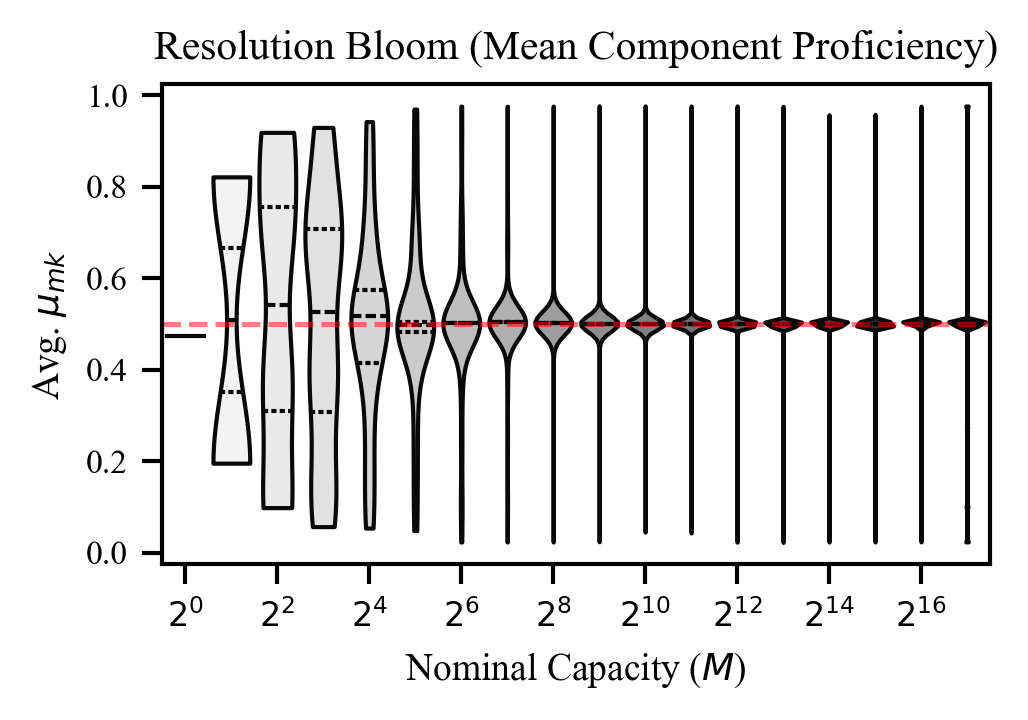

In [290]:
col_width = 3.5 
fig_height = 2.5

rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 10,          # Base font size
    "axes.titlesize": 10,     # Title size
    "axes.labelsize": 9,      # Axis labels
    "xtick.labelsize": 8,     # Tick labels
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 300
})

fig, ax2 = plt.subplots(figsize=(col_width, fig_height))
plt.subplots_adjust(hspace=0.5) # Increased space for readability

# --- PANEL 2: THE RESOLUTION BLOOM (Violin) ---
# Assuming 'df' is your long-form DataFrame from the previous step
sns.violinplot(data=df, x='M', y='Proficiency', inner="quart", ax=ax2, palette="Greys", cut=0, bw_method=0.35)
ax2.axhline(0.5, color='red', linestyle='--', alpha=0.5)
ax2.set_title("Resolution Bloom (Mean Component Proficiency)")
ax2.set_ylabel("Avg. $\\mu_{mk}$")
ax2.set_xlabel("Nominal Capacity ($M$)")

# 3. Apply the labels
pows = [int(np.log2(int(s.split("=")[-1]))) for s in df['M'].unique()]
pow_labels = [f'$2^{{{pow}}}$' for pow in pows]

indices = np.arange(len(unique_m))[::2]
pow_labels = [f'$2^{{{pows[i]}}}$' for i in indices]

# 3. Apply the subset to the axis
ax2.set_xticks(indices)
ax2.set_xticklabels(pow_labels)

plt.tight_layout()
plt.savefig("figures/component_violin_plot.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [279]:
indices

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16])

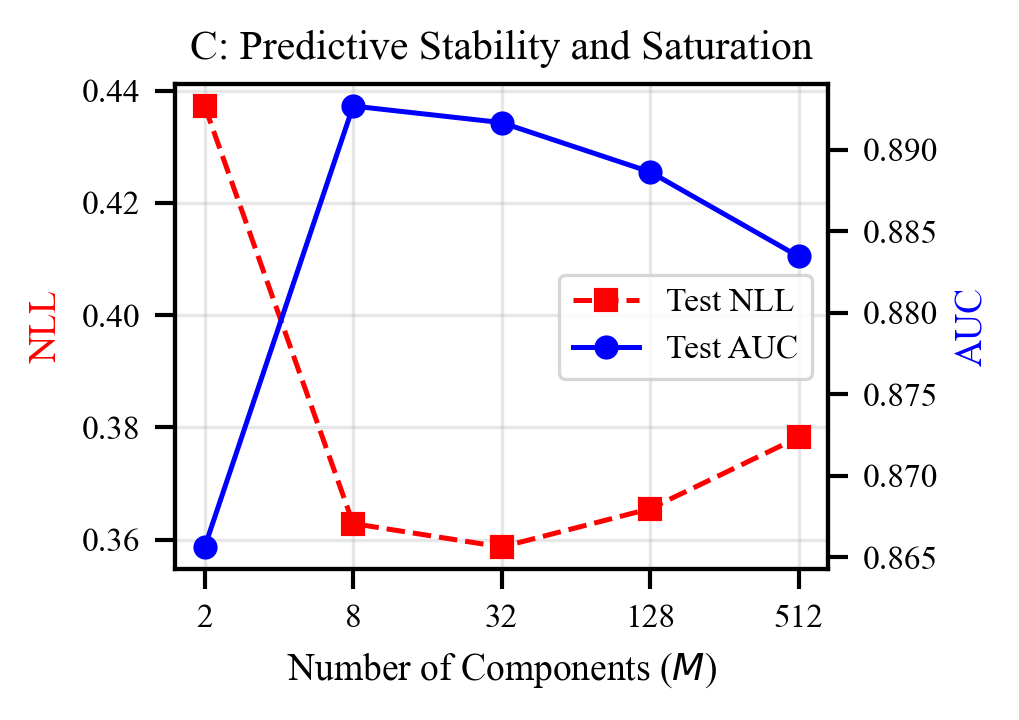

In [160]:
col_width = 3.5 
fig_height = 2.5

rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 10,          # Base font size
    "axes.titlesize": 10,     # Title size
    "axes.labelsize": 9,      # Axis labels
    "xtick.labelsize": 8,     # Tick labels
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 300
})

fig, ax3 = plt.subplots(figsize=(col_width, fig_height))

# --- PANEL 3: STABILITY (NLL/AUC) ---
# Dual-axis plot for the final panel
ax3_twin = ax3.twinx()
m_vals_perf = [2**k for k in range(1, 10, 2)]
# Replace with your actual mean performance data
test_auc = [0.8656178457213514, 0.8926837921522227, 0.8916669352558517, 0.8886420145421249, 0.8834514474500215]
test_nll = [0.4372715103392736, 0.36286104053359153, 0.3586875819363884, 0.36550615372770084, 0.37822787369900474]

lns1 = ax3.plot(m_vals_perf, test_nll, 's--', color='red', label='Test NLL')
lns2 = ax3_twin.plot(m_vals_perf, test_auc, 'o-', color='blue', label='Test AUC')

ax3.set_xscale('log', base=2)
ax3.set_xticks(m_vals_perf)
ax3.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax3.set_title("C: Predictive Stability and Saturation")
ax3.set_xlabel("Number of Components ($M$)")
ax3.set_ylabel("NLL", color='red')
ax3_twin.set_ylabel("AUC", color='blue')

# Combined Legend for dual axis
lns = lns1 + lns2
labs = [l.get_label() for l in lns]
ax3.legend(lns, labs, loc='center right', fontsize=8)
ax3.grid(True)

plt.tight_layout()
plt.savefig("figures/overfitting_test.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [169]:
diff_nll = (abs(min(test_nll) - test_nll[-1]))/ min(test_nll)
diff_auc = (abs(max(test_auc) - test_auc[-1]))/ max(test_auc)
print('Max NLL:', max(test_nll), ', Min NLL:', test_nll[-1], ", Pct diff:", diff_nll)
print('Max AUC:', max(test_auc), ', Min AUC:', test_auc[-1], ", Pct diff:", diff_auc)

Max NLL: 0.4372715103392736 , Min NLL: 0.37822787369900474 , Pct diff: 0.05447719058777376
Max AUC: 0.8926837921522227 , Min AUC: 0.8834514474500215 , Pct diff: 0.010342234040054042


/var/folders/vk/bnzg451d24310v57025d6tmw0000gn/T/ipykernel_24304/822862537.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='M', y='Proficiency', inner="quart", ax=ax2, palette="Greys", cut=0)


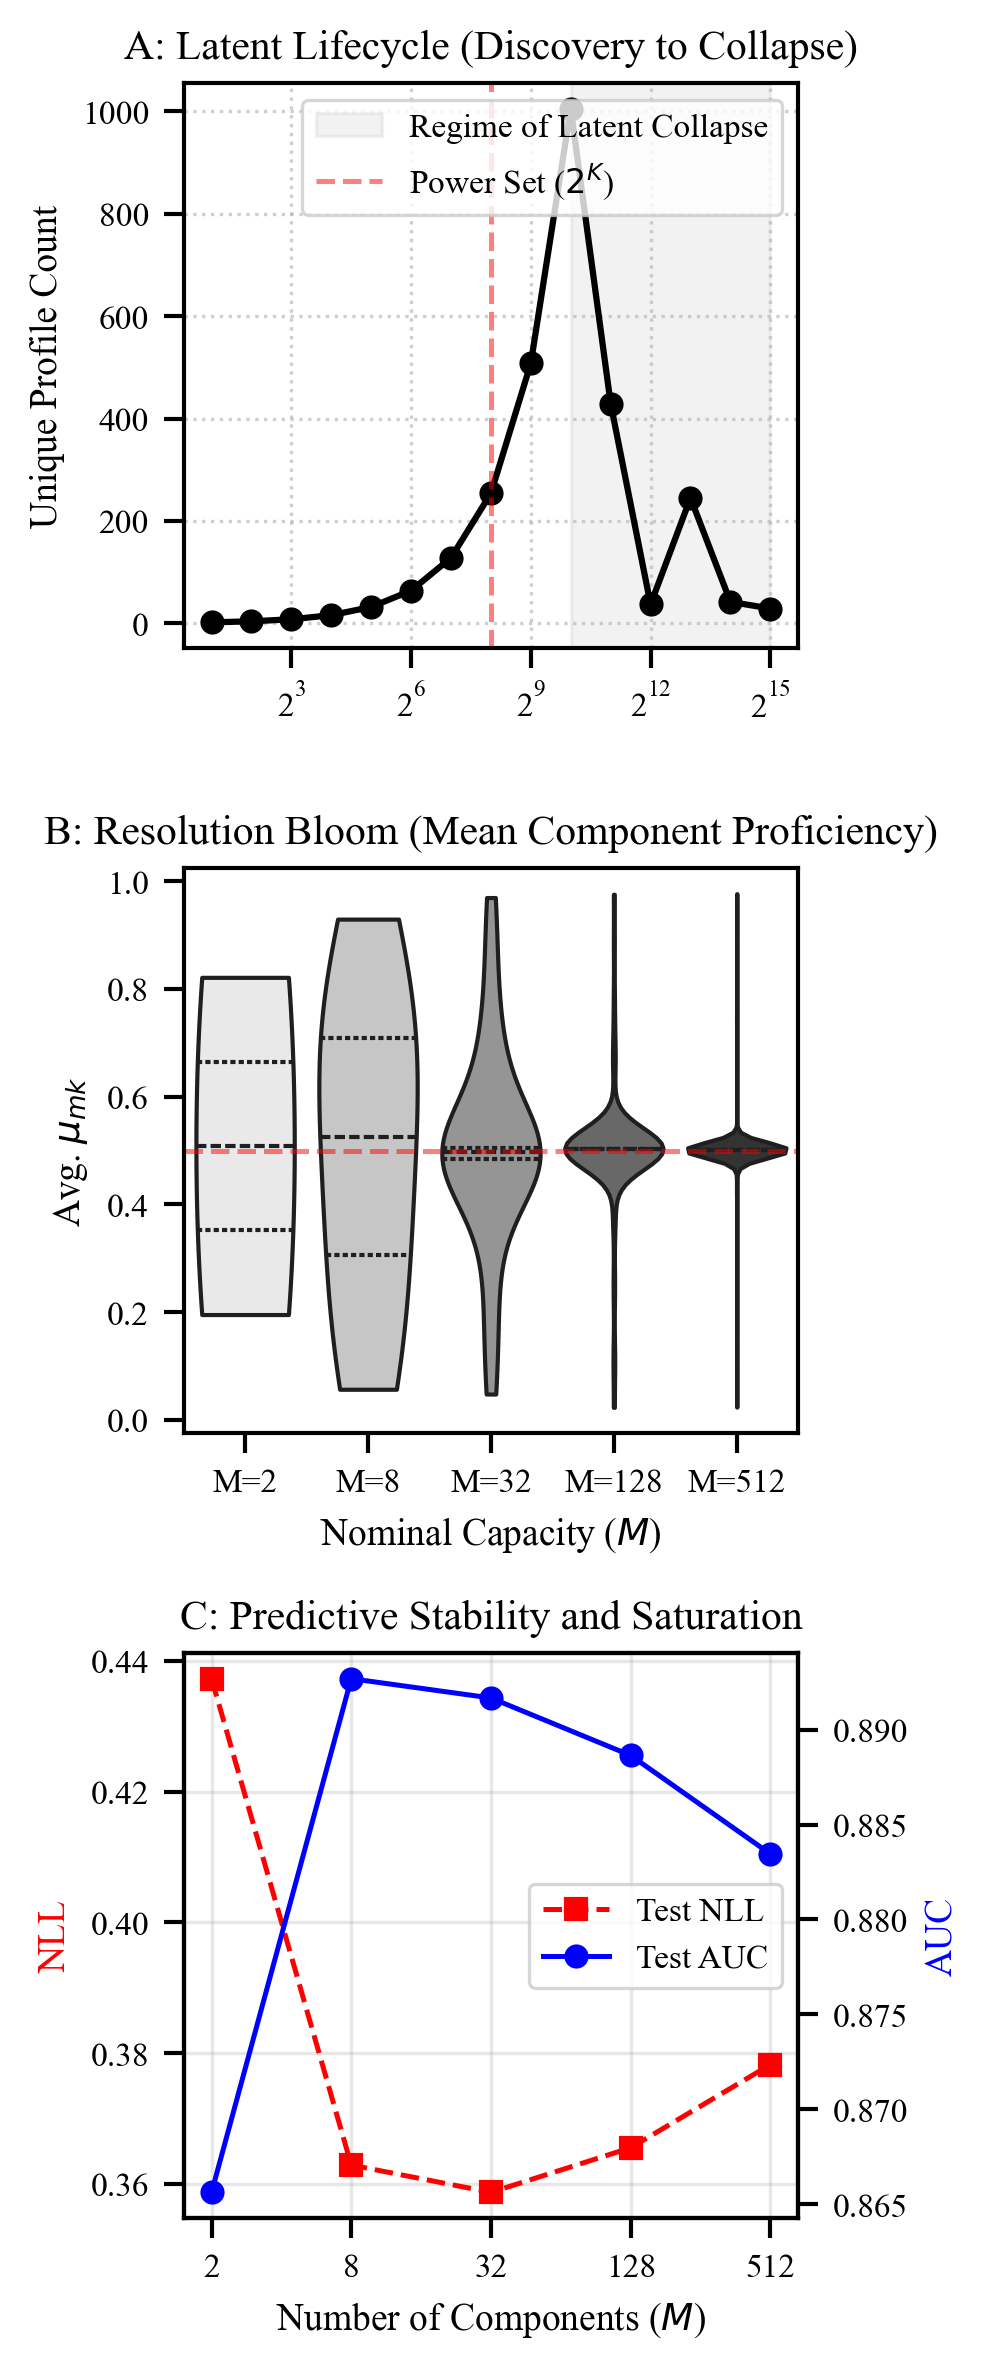

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import rcParams

# We make it taller (9 inches) to accommodate the 3-panel stack
col_width = 3.4 
fig_height = 8

rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 10,          # Base font size
    "axes.titlesize": 10,     # Title size
    "axes.labelsize": 9,      # Axis labels
    "xtick.labelsize": 8,     # Tick labels
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 300
})

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(col_width, fig_height))
plt.subplots_adjust(hspace=0.5) # Increased space for readability

# --- PANEL 1: THE LATENT LIFECYCLE ---
m_vals_lifecycle = [2**k for k in range(1, 16, 1)]
# Replace with your actual comp_counts data
comp_counts = [2, 4, 8, 16, 32, 64, 128, 254, 508, 1005, 429, 37, 245, 42, 29] 
ax1.plot(m_vals_lifecycle, comp_counts, 'o-', color='black', linewidth=1.5)
ax1.axvspan(1024, m_values[-1], color='gray', alpha=0.1, label='Regime of Latent Collapse')
ax1.axvline(256, color='red', linestyle='--', alpha=0.5, label='Power Set ($2^K$)')
ax1.set_xscale('log', base=2)
ax1.set_ylabel("Unique Profile Count")
ax1.set_title("A: Latent Lifecycle (Discovery to Collapse)")
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(fontsize=8)

# --- PANEL 2: THE RESOLUTION BLOOM (Violin) ---
# Assuming 'df' is your long-form DataFrame from the previous step
sns.violinplot(data=df, x='M', y='Proficiency', inner="quart", ax=ax2, palette="Greys", cut=0)
ax2.axhline(0.5, color='red', linestyle='--', alpha=0.5)
ax2.set_title("B: Resolution Bloom (Mean Component Proficiency)")
ax2.set_ylabel("Avg. $\\mu_{mk}$")
ax2.set_xlabel("Nominal Capacity ($M$)")

# --- PANEL 3: STABILITY (NLL/AUC) ---
# Dual-axis plot for the final panel
ax3_twin = ax3.twinx()
m_vals_perf = [2**k for k in range(1, 10, 2)]
# Replace with your actual mean performance data
test_auc = [0.8656178457213514, 0.8926837921522227, 0.8916669352558517, 0.8886420145421249, 0.8834514474500215]
test_nll = [0.4372715103392736, 0.36286104053359153, 0.3586875819363884, 0.36550615372770084, 0.37822787369900474]

lns1 = ax3.plot(m_vals_perf, test_nll, 's--', color='red', label='Test NLL')
lns2 = ax3_twin.plot(m_vals_perf, test_auc, 'o-', color='blue', label='Test AUC')

ax3.set_xscale('log', base=2)
ax3.set_xticks(m_vals_perf)
ax3.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax3.set_title("C: Predictive Stability and Saturation")
ax3.set_xlabel("Number of Components ($M$)")
ax3.set_ylabel("NLL", color='red')
ax3_twin.set_ylabel("AUC", color='blue')

# Combined Legend for dual axis
lns = lns1 + lns2
labs = [l.get_label() for l in lns]
ax3.legend(lns, labs, loc='center right', fontsize=8)
ax3.grid(True)

plt.tight_layout()
plt.savefig("figures/structural_integrity_stack.pdf", format='pdf', bbox_inches='tight')
plt.show()


In [66]:
# import matplotlib.pyplot as plt
# import pandas as pd
# import numpy as np
# from matplotlib import rcParams

# # 1. Publication Configuration
# rcParams.update({
#     "font.family": "serif",
#     "font.serif": ["Times New Roman"],
#     "axes.labelsize": 12,
#     "axes.titlesize": 14,
#     "xtick.labelsize": 10,
#     "ytick.labelsize": 10,
#     "grid.alpha": 0.3
# })

# fig, ax = plt.subplots(figsize=(9, 5), dpi=300)

# # 2. Plot lines with high transparency
# # Components near 0.5 will "stack" their alpha, creating a dense dark band
# ax.plot(model.mu.T, color='black', alpha=0.20, linewidth=0.4)

# # 3. Add the theoretical Maximum Entropy horizon
# ax.axhline(0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Max Entropy ($\mu=0.5$)')

# # 4. Refine Axis and Labels
# ax.set_ylabel("Estimated Proficiency ($\\mu_{mk}$)", fontsize=13)
# ax.set_xlabel("Skill Index ($k$)", fontsize=13)
# ax.set_ylim(-0.05, 1.05)
# ax.set_title("Latent Component Collapse in Over-Specified MoLA ($M=100,000$)", pad=15)

# # 5. Clean up X-axis ticks
# ax.set_xticks(range(model.mu.shape[1]))
# ax.grid(True, axis='y', linestyle=':')

# # 6. Add a "Density" Marginal Plot (Optional but highly recommended for 0.5 proof)
# # This shows exactly where the "mass" of the 5,000 components sits
# ax_hist = ax.inset_axes([1.02, 0, 0.08, 1], sharey=ax)
# ax_hist.hist(model.mu.flatten(), bins=100, orientation='horizontal', color='gray', alpha=0.4)
# ax_hist.set_axis_off()
# ax_hist.set_title("Density", fontsize=10)

# plt.tight_layout()
# plt.show()


In [62]:
# import matplotlib.pyplot as plt
# import numpy as np
# from matplotlib import rcParams

# # 1. High-End Publication Config
# rcParams.update({
#     "font.family": "serif",
#     "font.serif": ["Times New Roman"],
#     "axes.linewidth": 1.0,
#     "figure.dpi": 300
# })

# fig, ax = plt.subplots(figsize=(10, 6))

# # 2. Plotting with "Filament" Alpha
# # 100k lines need a microscopic alpha to avoid a solid black block.
# # This makes the 0.5 collapse look like a "singularity" and the unique 
# # profiles look like rare, interesting trajectories.
# ax.plot(model.mu.T, color='black', alpha=0.2, linewidth=0.3, zorder=1)

# # 3. Highlight the "Event Horizon" at 0.5
# ax.axhline(0.5, color='#d62728', linestyle='--', linewidth=1.2, alpha=0.8, 
#            label='Maximum Entropy ($\mu=0.5$)', zorder=3)

# # 4. Marginal Density with Log-Scale (The "Secret Sauce")
# # Log scale ensures that the 67 unique profiles aren't invisible 
# # compared to the 99,933 redundant ones.
# ax_hist = ax.inset_axes([1.01, 0, 0.12, 1], sharey=ax)
# counts, bins, _ = ax_hist.hist(model.mu.flatten(), bins=150, 
#                                orientation='horizontal', color='black', alpha=0.2)
# ax_hist.set_xscale('log') # This makes the "spiky" profiles visible on the histogram!
# ax_hist.set_axis_off()
# ax_hist.set_title("Log-Density", fontsize=9, pad=10)

# # 5. Styling
# ax.set_ylabel("Estimated Proficiency ($\\mu_{mk}$)", fontsize=14, labelpad=10)
# ax.set_xlabel("Skill Index ($k$)", fontsize=14, labelpad=10)
# ax.set_title("Latent Singularity: 100k-Component Collapse ($K=8$)", fontsize=16, pad=20)
# ax.set_ylim(-0.02, 1.02)
# ax.set_xticks(range(model.mu.shape[1]))
# ax.grid(True, axis='y', linestyle=':', alpha=0.6)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

# # 6. Add Annotation
# unique_count = model.mu.shape[0] - pd.DataFrame(model.mu).duplicated().sum()
# ax.annotate(f"Total Components: 100,000\nUnique Archetypes: {unique_count}", 
#             xy=(0.02, 0.95), xycoords='axes fraction', 
#             fontsize=11, verticalalignment='top', 
#             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='0.8'))

# plt.tight_layout()
# plt.savefig("figures/latent_collapse_plot.pdf", format='pdf', bbox_inches='tight')
# plt.show()


<>:46: SyntaxWarning: invalid escape sequence '\m'
<>:46: SyntaxWarning: invalid escape sequence '\m'
/var/folders/vk/bnzg451d24310v57025d6tmw0000gn/T/ipykernel_24304/2175628321.py:46: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("Estimated Proficiency ($\mu_{mk}$)", fontsize=14)


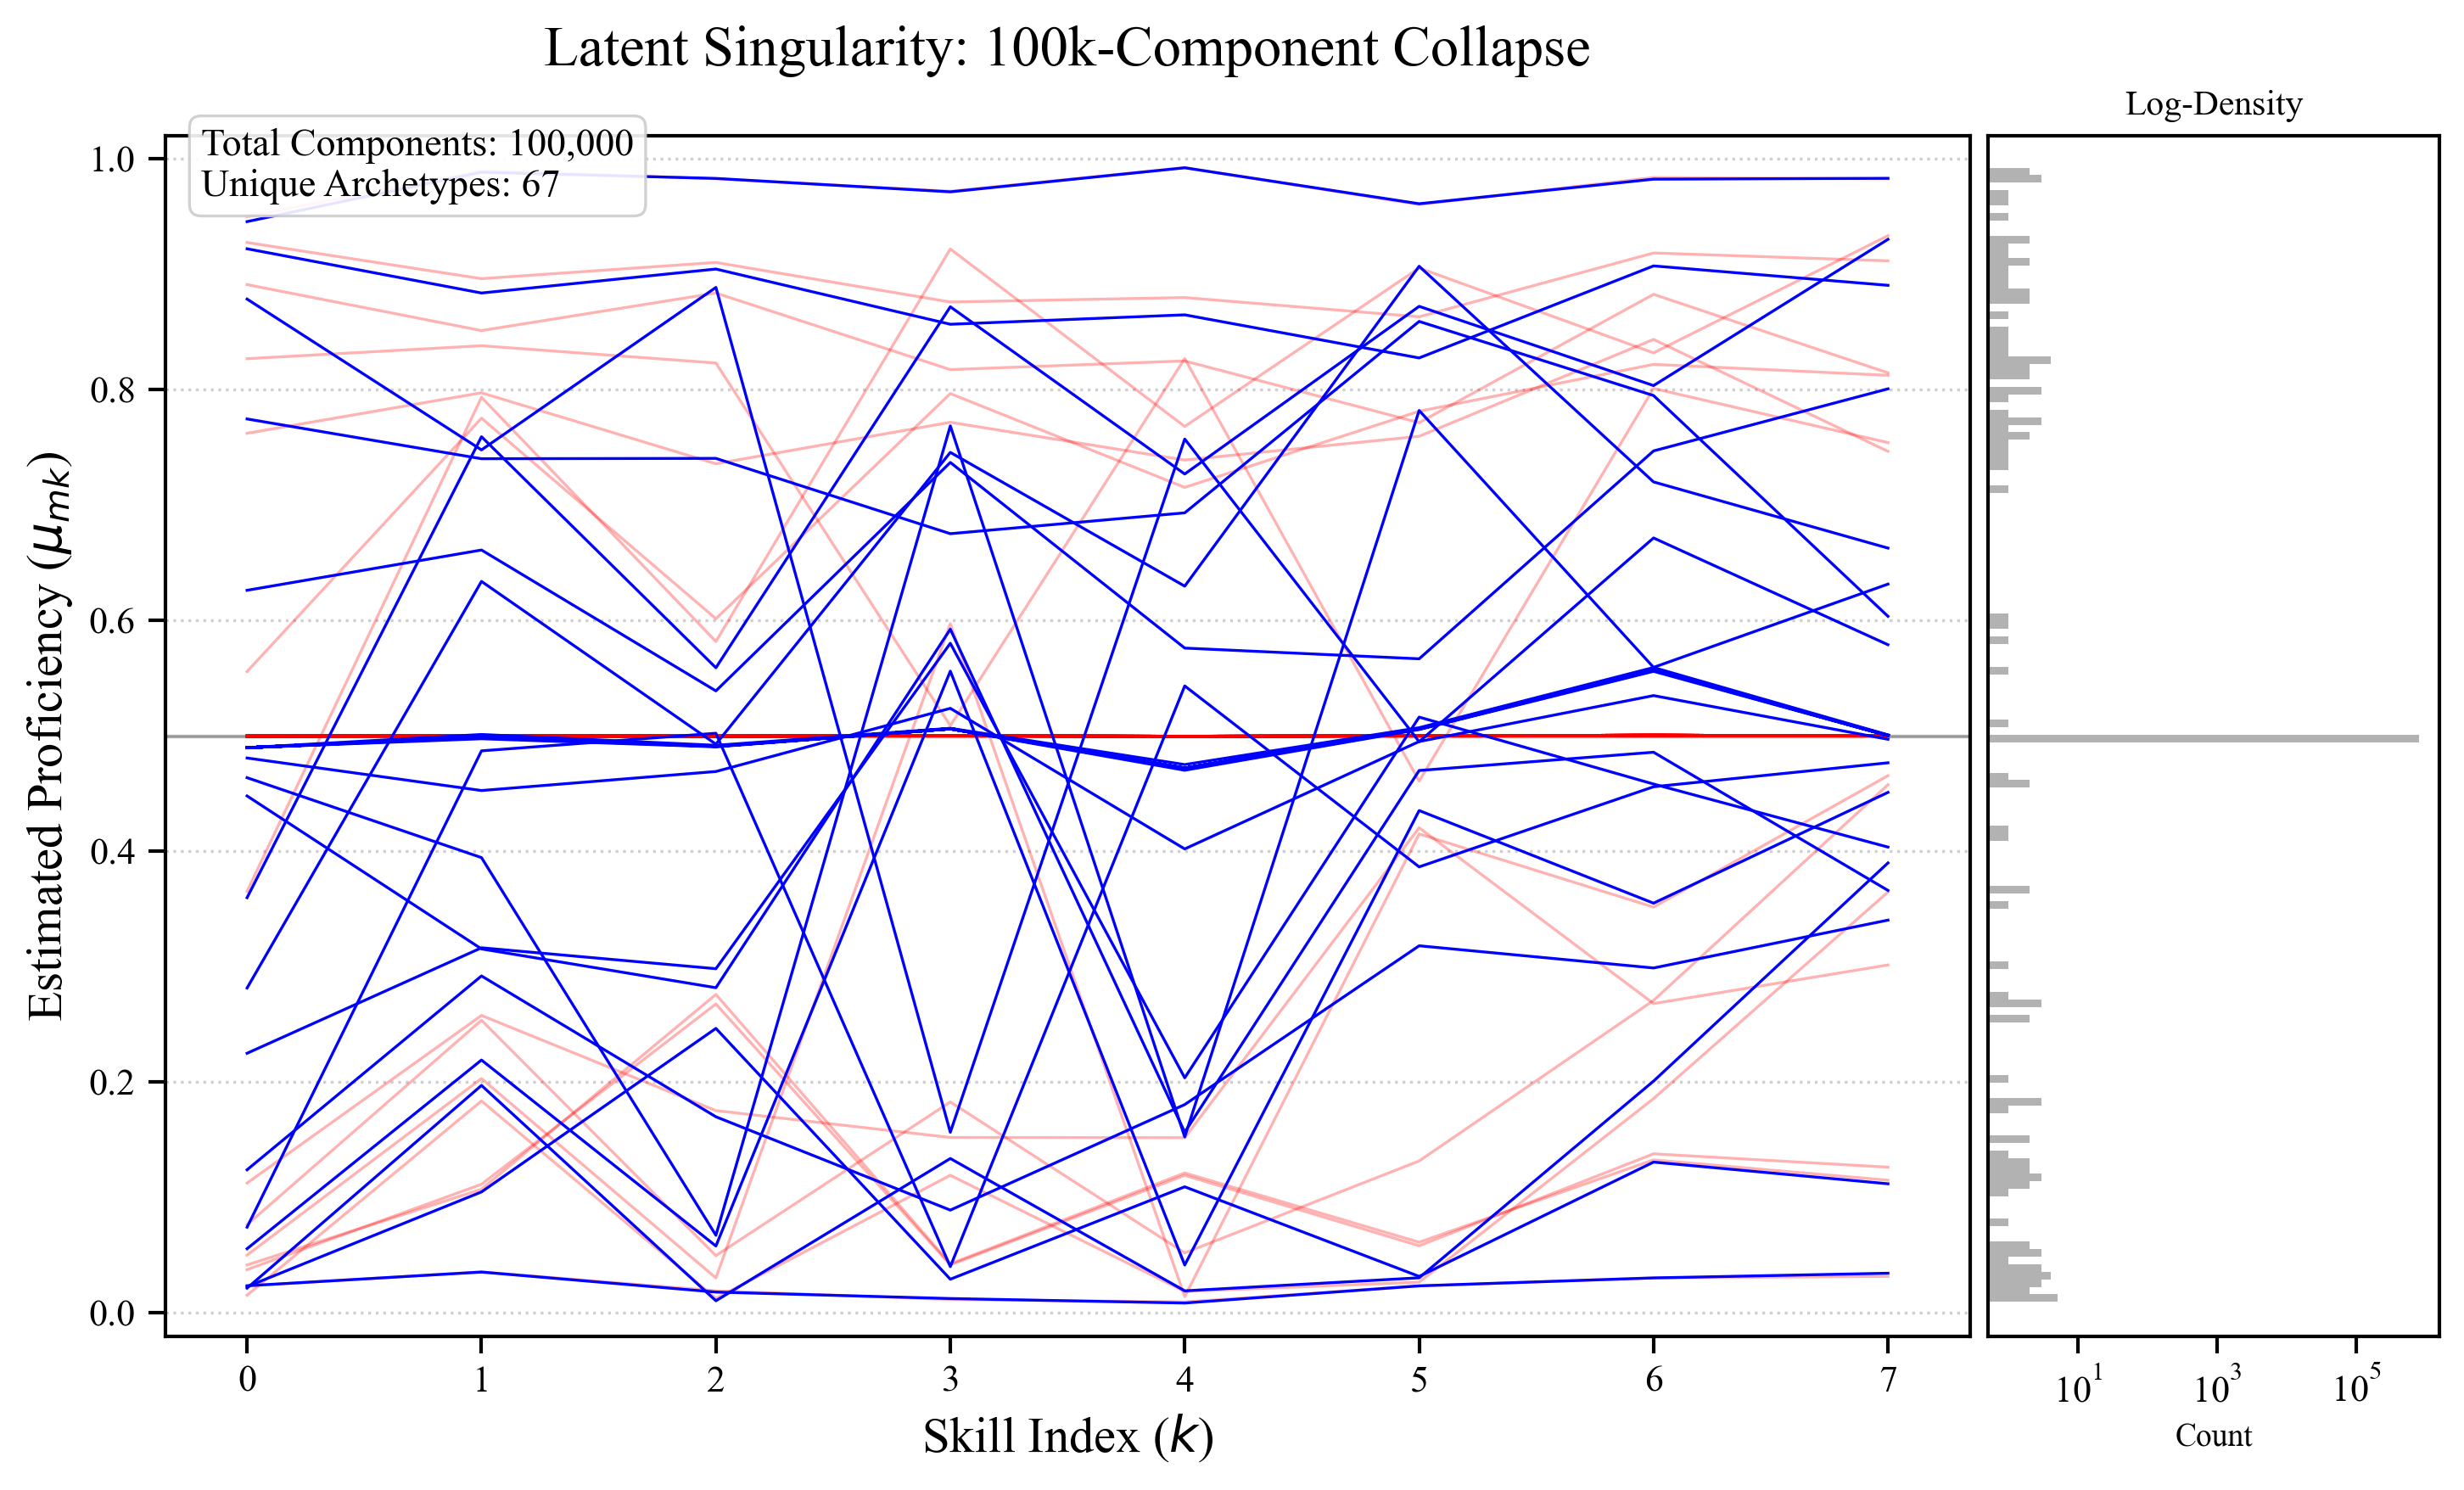

In [75]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib import rcParams

# 1. Configuration
rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "figure.dpi": 300
})

# Identify Unique vs Redundant
df_mu = pd.DataFrame(model.mu)
is_duplicate = df_mu.duplicated(keep='first')
unique_mu = model.mu[~is_duplicate]
redundant_mu = model.mu[is_duplicate]
unique_count = len(unique_mu)

fig, ax = plt.subplots(figsize=(10, 6))

# 2. REPRESENT REDUNDANCY (The 99k+ lines)
# Instead of 99k lines, we plot a single "glow" or band to show the mass
# The spread (y-range) shows that they aren't EXACTLY 0.5, but close.
y_min, y_max = redundant_mu.min(), redundant_mu.max()
ax.axhspan(y_min, y_max, color='black', alpha=0.3, label='Redundant Mass', zorder=1)

# 3. PLOT UNIQUE ARCHETYPES (The ~67 lines)
# These render instantly because there are so few of them
ax.plot(unique_mu.T, color='red', alpha=0.3, linewidth=0.8, zorder=2)
ax.plot(model_small.mu.T, color='blue', linewidth=0.8)

# # 4. REFERENCE LINE
# ax.axhline(0.5, color='#d62728', linestyle='--', linewidth=1.2, alpha=0.8, 
#            label='Max Entropy ($\\mu=0.5$)', zorder=3)

# 5. MARGINAL LOG-DENSITY (Use all data here, hist is fast)
ax_hist = ax.inset_axes([1.01, 0, 0.25, 1], sharey=ax)
ax_hist.hist(model.mu.flatten(), bins=150, orientation='horizontal', color='black', alpha=0.3)
ax_hist.set_xscale('log')
ax_hist.set_xlabel("Count", fontsize=9)
ax_hist.set_title("Log-Density", fontsize=10)
ax_hist.yaxis.set_visible(False)

# 6. STYLING
ax.set_ylabel("Estimated Proficiency ($\mu_{mk}$)", fontsize=14)
ax.set_xlabel("Skill Index ($k$)", fontsize=14)
ax.set_title("Latent Singularity: 100k-Component Collapse", fontsize=16, pad=20)
ax.set_ylim(-0.02, 1.02)
ax.set_xticks(range(model.mu.shape[1]))
ax.grid(True, axis='y', linestyle=':', alpha=0.6)

# Annotation
ax.annotate(f"Total Components: 100,000\nUnique Archetypes: {unique_count}", 
            xy=(0.02, 0.95), xycoords='axes fraction', fontsize=11, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='0.8'))

plt.tight_layout()
plt.savefig("figures/latent_collapse_plot.pdf", format='pdf', bbox_inches='tight')
plt.show()


<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
/var/folders/vk/bnzg451d24310v57025d6tmw0000gn/T/ipykernel_24304/2203934614.py:48: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("Estimated Proficiency ($\mu_{mk}$)", fontsize=14)


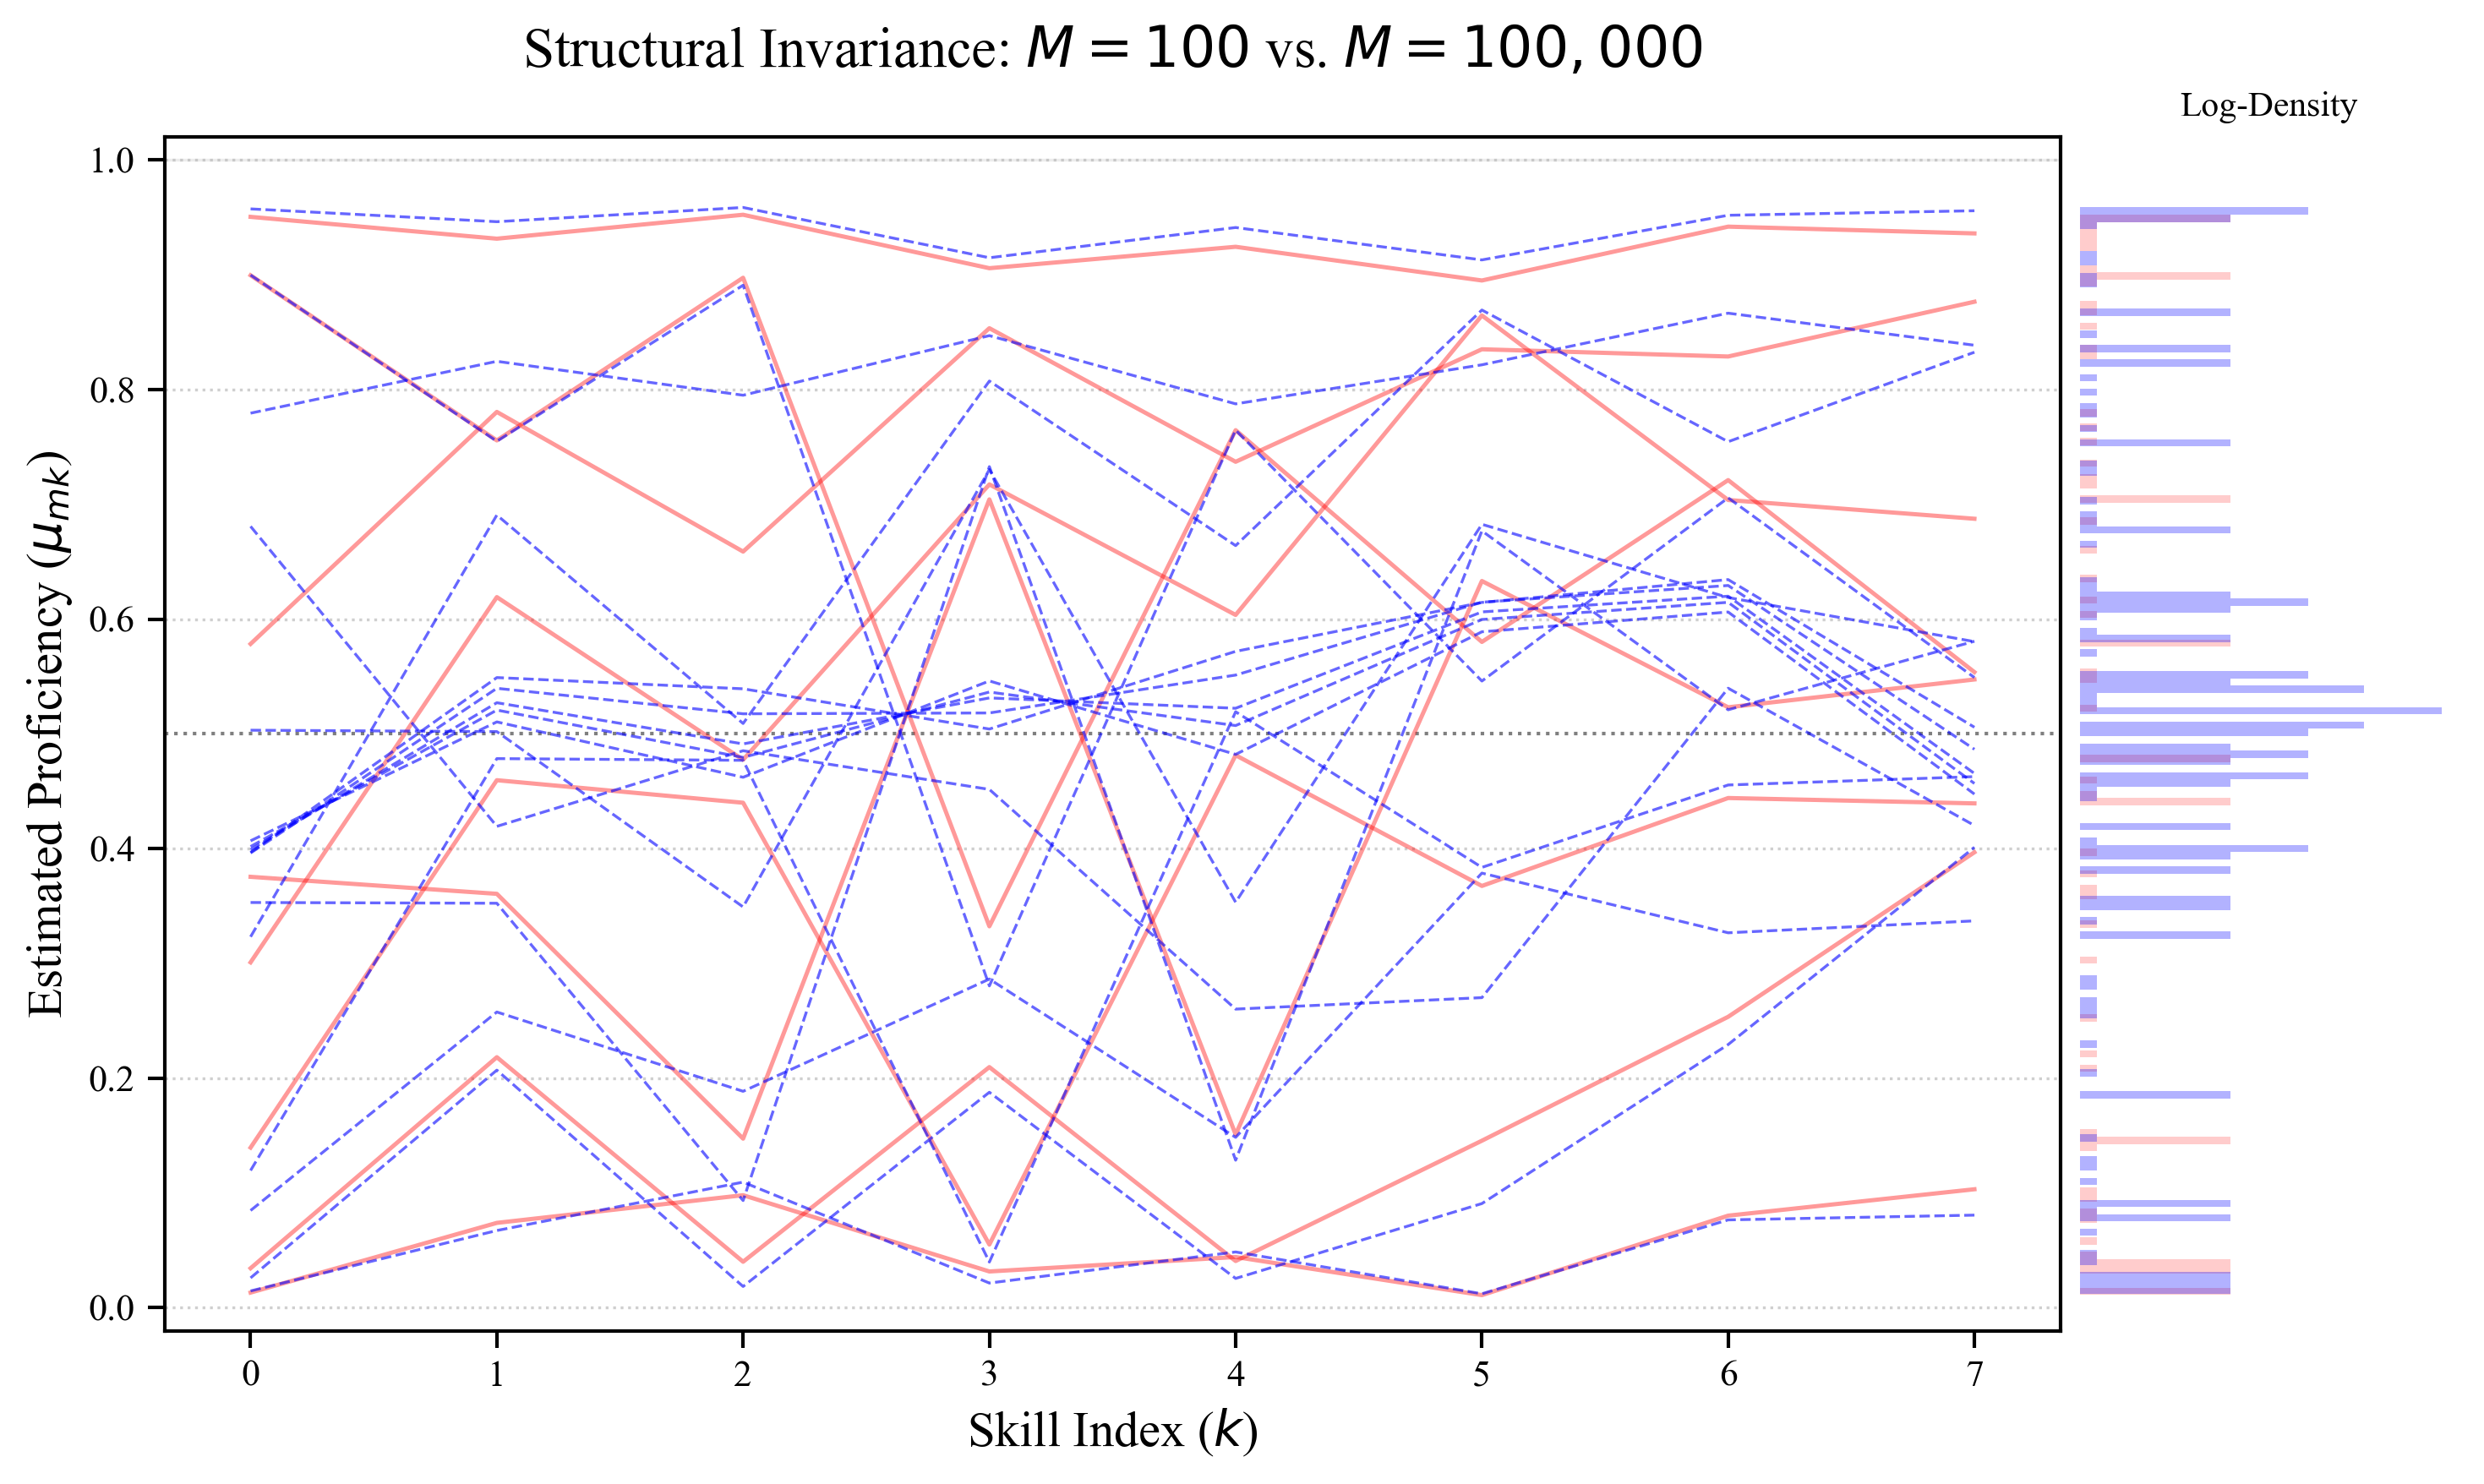

In [82]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib import rcParams

# 1. Configuration
rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "figure.dpi": 300
})

# Data Preparation for M=100k
df_mu = pd.DataFrame(model.mu)
is_duplicate = df_mu.duplicated(keep='first')
unique_mu_large = model.mu[~is_duplicate]
redundant_mu = model.mu[is_duplicate]

# Data Preparation for M=100
df_mu_small = pd.DataFrame(model_small.mu)
is_dup_small = df_mu_small.duplicated(keep='first')
unique_mu_small = model_small.mu[~is_dup_small]

fig, ax = plt.subplots(figsize=(10, 6))

# 2. THE BACKGROUND "SHADOW" (Redundant Mass of 100k)
# Represents the 99,933 components that "neutralized"
y_min, y_max = 1, 1 #redundant_mu.min().min(), redundant_mu.max().max()
ax.axhspan(y_min, y_max, color='gray', alpha=0.15, label='Redundant Mass ($M=100k$)', zorder=1)

# 3. THE "GOLDEN PROFILES" (Comparison)
# Plotting the unique archetypes from both models to show they find the same patterns
ax.plot(unique_mu_large.T, color='red', alpha=0.4, linewidth=1.2, label=f'Unique Archetypes ($M=100k$, $n={len(unique_mu_large)}$)', zorder=3)
ax.plot(unique_mu_small.T, color='blue', alpha=0.6, linewidth=0.8, linestyle='--', label=f'Unique Archetypes ($M=100$, $n={len(unique_mu_small)}$)', zorder=4)

# 4. REFERENCE HORIZON
ax.axhline(0.5, color='black', linestyle=':', linewidth=1, alpha=0.5, zorder=2)

# 5. MARGINAL LOG-DENSITY
ax_hist = ax.inset_axes([1.01, 0, 0.20, 1], sharey=ax)
ax_hist.hist(model.mu.flatten(), bins=150, orientation='horizontal', color='red', alpha=0.2, label='100k Density')
ax_hist.hist(model_small.mu.flatten(), bins=150, orientation='horizontal', color='blue', alpha=0.3, label='100 Density')
ax_hist.set_xscale('log')
ax_hist.set_axis_off()
ax_hist.set_title("Log-Density", fontsize=10)

# 6. STYLING
ax.set_ylabel("Estimated Proficiency ($\mu_{mk}$)", fontsize=14)
ax.set_xlabel("Skill Index ($k$)", fontsize=14)
ax.set_title("Structural Invariance: $M=100$ vs. $M=100,000$", fontsize=16, pad=20)
ax.set_ylim(-0.02, 1.02)
ax.set_xticks(range(model.mu.shape[1]))
ax.grid(True, axis='y', linestyle=':', alpha=0.6)
# ax.legend(loc='lower left', fontsize=9, frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.savefig("figures/latent_invariance_plot.pdf", format='pdf', bbox_inches='tight')
plt.show()


In [48]:
redundant_count = pd.DataFrame(model.mu).duplicated().sum()
print('Number of effective components:', model.mu.shape[0] - redundant_count)

def compute_effective_m(weights):
    # weights: array of mixture proportions (pi_m) that sum to 1
    # Add a tiny epsilon to avoid log(0)
    eps = 1e-12
    entropy = -np.sum(weights * np.log(weights + eps))
    return np.exp(entropy)

m_eff = compute_effective_m(model.pi)
print(f"Effective Number of Components (M_eff): {m_eff:.2f}")

Number of effective components: 67
Effective Number of Components (M_eff): 98943.05


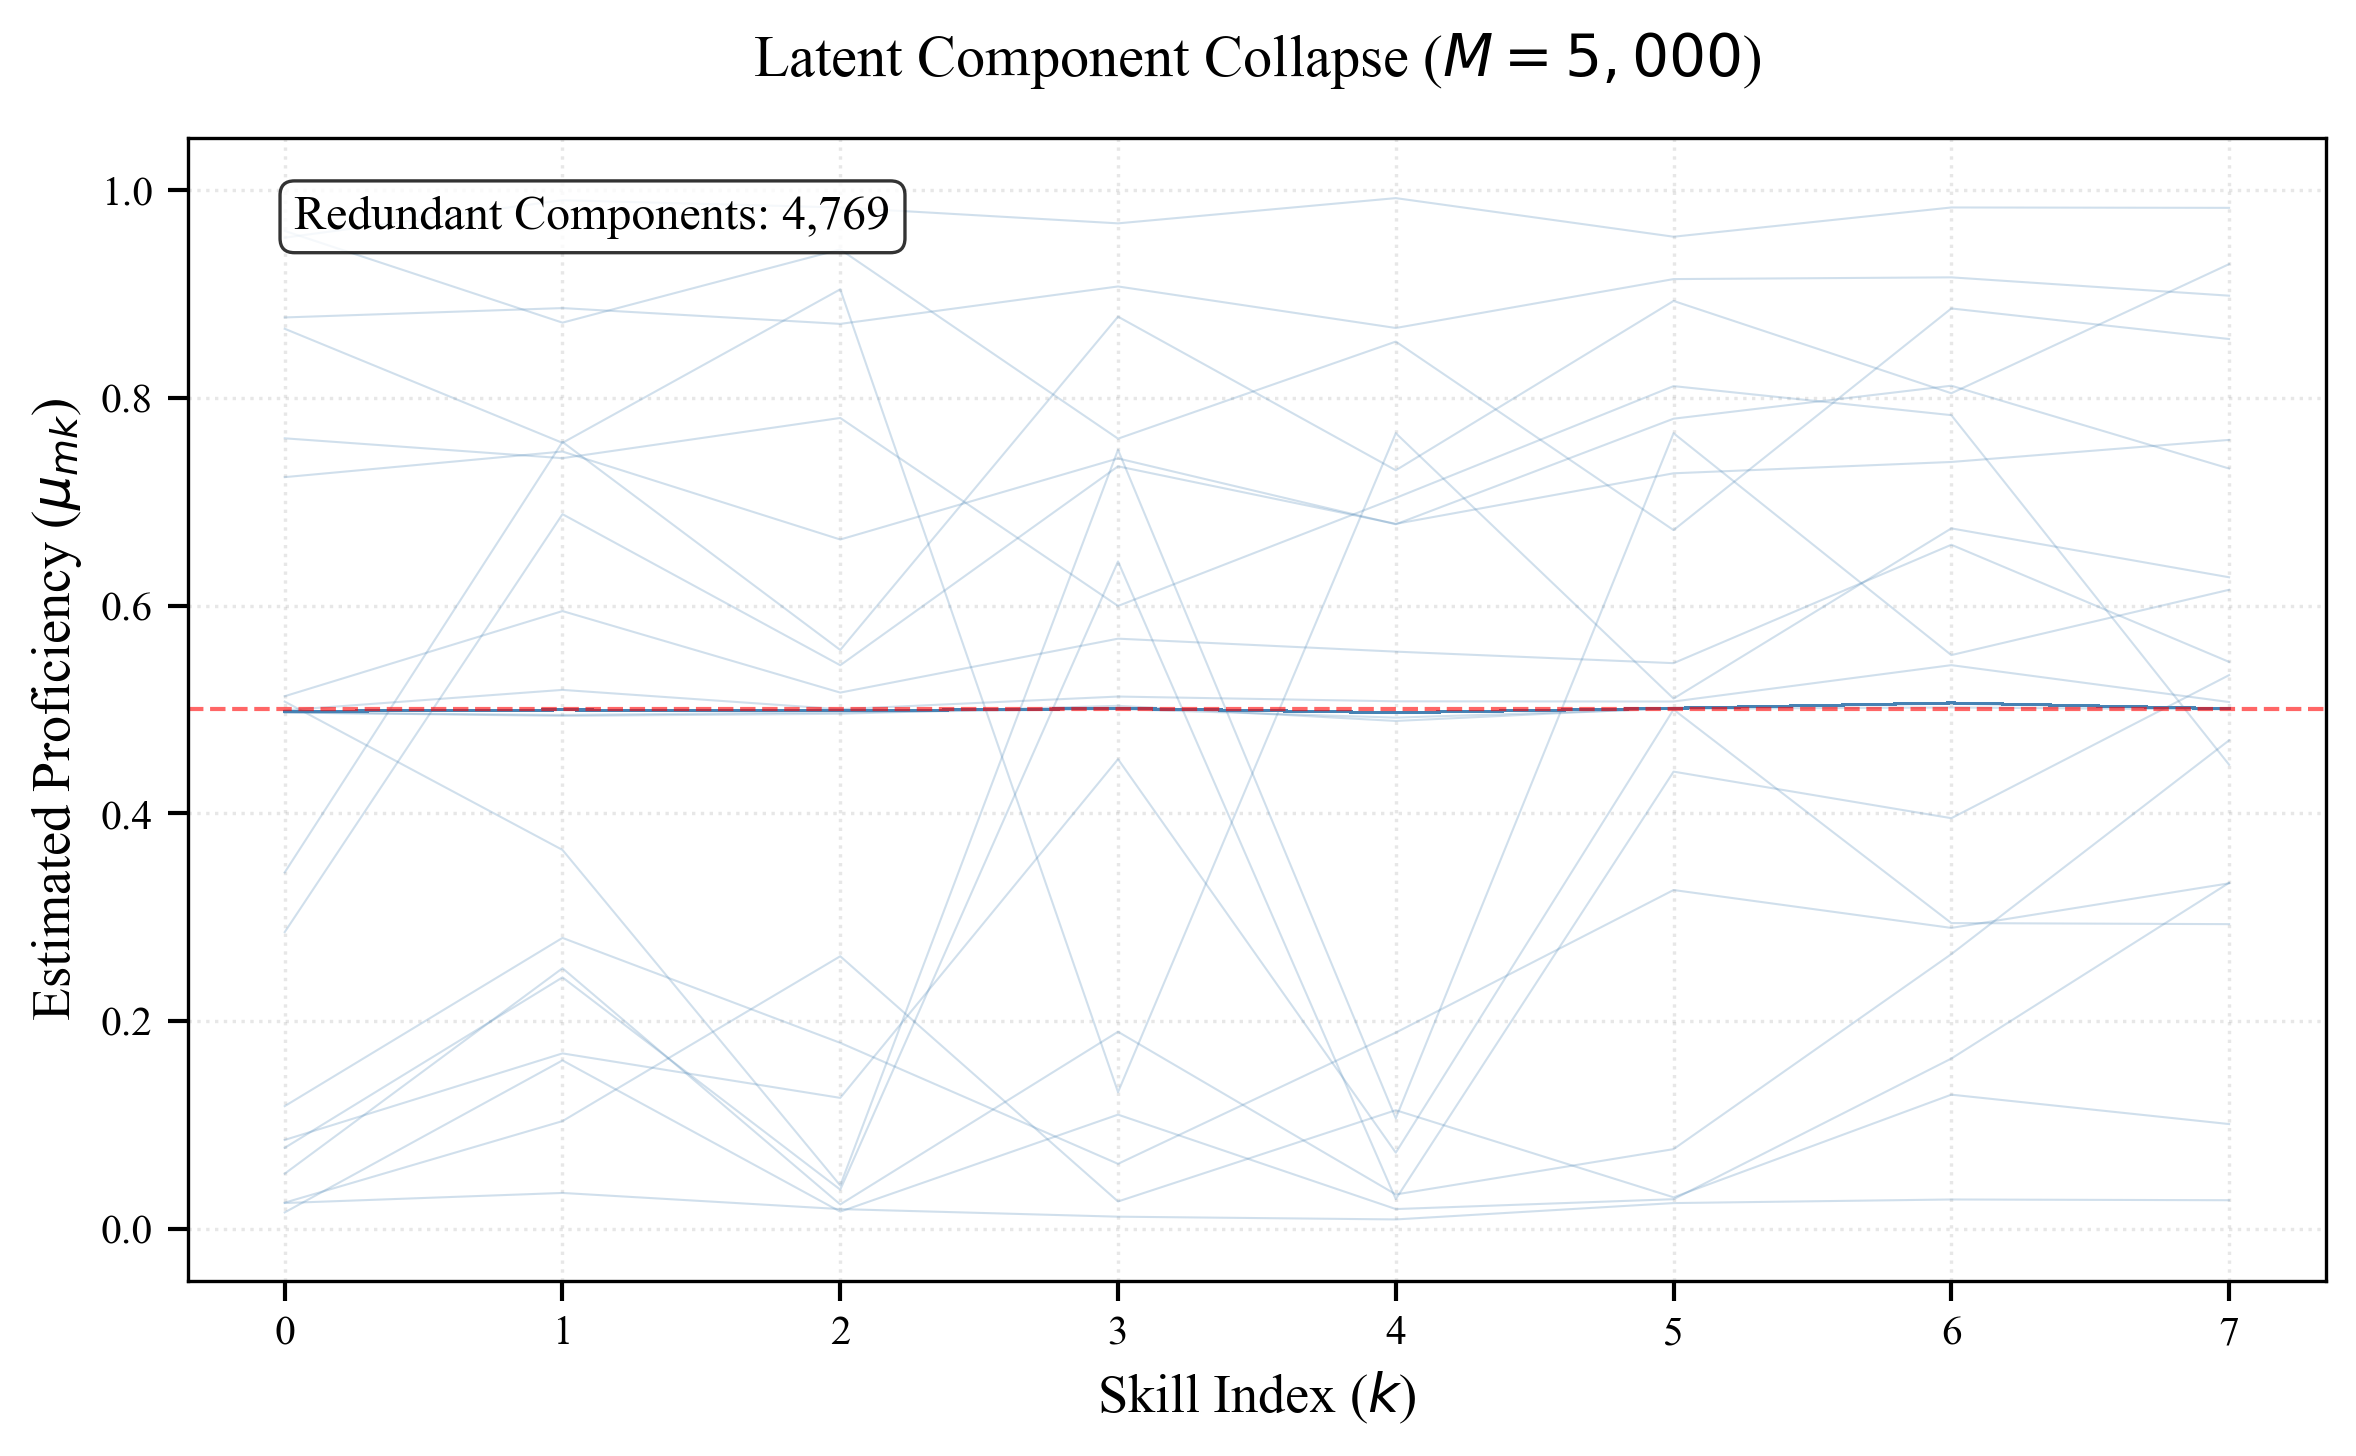

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# 1. Standard Publication Configuration
rcParams.update({
    "text.usetex": False,      # Set to True if you have a full TeX distribution installed
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "grid.alpha": 0.3
})

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

# 2. Plotting with Transparency (Alpha)
# Low alpha allows redundant components to stack, appearing darker/bolder at 0.5
ax.plot(model.mu.T, color='steelblue', alpha=0.25, linewidth=0.5)

# 3. Add a explicit reference line at the neutral 0.5 proficiency
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, alpha=0.6, label='Neutral Baseline (0.5)')

# 4. Refine Labels and Aesthetics
ax.set_ylabel("Estimated Proficiency ($\\mu_{mk}$)", fontsize=13)
ax.set_xlabel("Skill Index ($k$)", fontsize=13)
ax.set_title(f"Latent Component Collapse ($M=5,000$)", pad=15)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, linestyle=':')

# 5. Clean up the X-axis (ensure skill indices are integers)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# 6. Optional: Add a text annotation for the redundancy count
redundant_count = pd.DataFrame(model.mu).duplicated().sum()
ax.text(0.05, 0.95, f"Redundant Components: {redundant_count:,}", 
        transform=ax.transAxes, verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig("figures/latent_collapse_plot.pdf", format='pdf', bbox_inches='tight') # PDF for infinite zoom
plt.show()


## Step 3: Visualize Training Results

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

### Step 3b: Visualize Convergence Curve

Negative Log-Likelihood: 0.02067689706993412


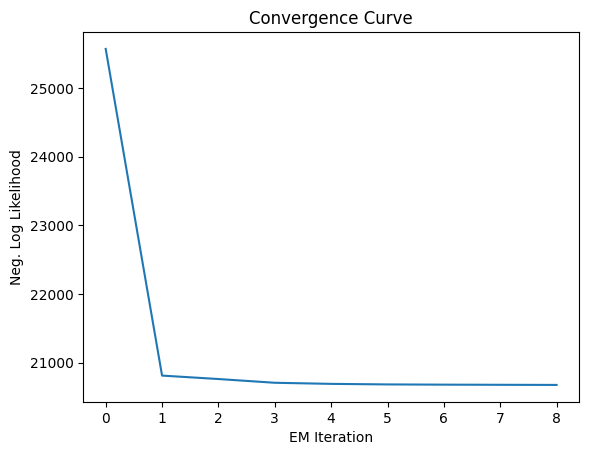

In [9]:
import matplotlib.pyplot as plt
print("Negative Log-Likelihood:", model.nll_trace[-1] * (1e-6))

plt.plot(model.nll_trace)
plt.title('Convergence Curve')
plt.ylabel('Neg. Log Likelihood')
plt.xlabel('EM Iteration')
plt.show()

### Step 3b: Visualize Proficiency Components

<>:57: SyntaxWarning: invalid escape sequence '\m'
<>:57: SyntaxWarning: invalid escape sequence '\m'
/var/folders/vk/bnzg451d24310v57025d6tmw0000gn/T/ipykernel_12604/975017048.py:57: SyntaxWarning: invalid escape sequence '\m'
  fig.supylabel("Estimated Proficiency ($\mu_{mk}$)", fontsize=13)


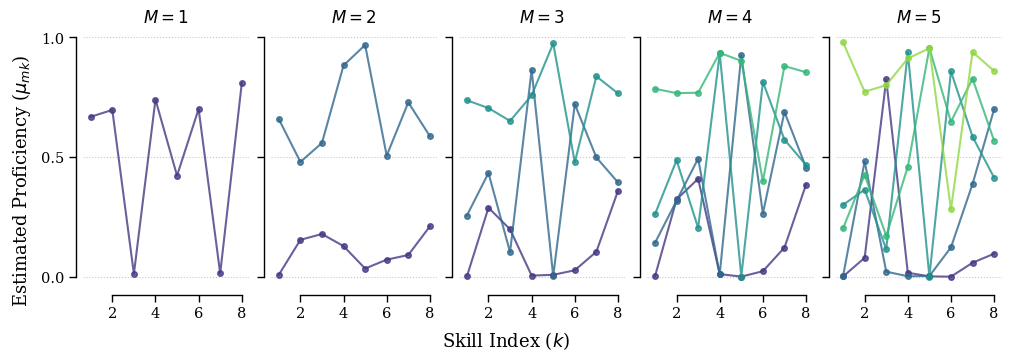

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from aplus.cognitive_model import MoLA

# Set plotting context for Academic Paper
sns.set_context("paper", font_scale=1.2)
plt.rcParams['font.family'] = 'serif' # Matches LaTeX default
plt.rcParams['axes.unicode_minus'] = False

component_list = [1, 2, 3, 4, 5]
n = len(component_list)

# Use a professional, high-contrast palette
"rocket"
colors = sns.color_palette("viridis", n_colors=max(component_list))

fig, axes = plt.subplots(1, n, figsize=(10, 3.5), sharey=True, constrained_layout=True)

for i, (ax, n_comp) in enumerate(zip(axes, component_list)):
    # Standardize model setup
    model_params = {
        'Q_matrix': Q_matrix,
        'n_components': n_comp,
        'mu_smooth': [2, 2],
        'theta_smooth': [2, 2],
        'pi_smooth': 1,
        'tol': 1e-5,
        'n_iter': 100, # Increased for stability
        'random_state': 42, # Reproducibility is key for papers
        'use_psuedo_likelihood': False
    }
    
    model_qual = MoLA(**model_params)
    model_qual.fit(X)
    
    # Sort components by mean proficiency to keep colors consistent across plots
    # This makes M=2 and M=3 look like evolutions of each other
    sorted_idx = np.argsort(model_qual.mu.mean(axis=1))
    
    for rank, k in enumerate(sorted_idx):
        ax.plot(range(1, model_qual.mu.shape[1] + 1), model_qual.mu[k, :], 
                color=colors[rank], 
                marker='o', markersize=4, 
                linewidth=1.5, alpha=0.8)
    
    ax.set_title(f'$M={n_comp}$', fontsize=12, fontweight='bold')
    ax.set_xticks([2, 4, 6, 8]) # Show only key indices to prevent crowding
    ax.set_yticks([0.0, 0.5, 1.0])
    ax.grid(axis='y', linestyle=':', alpha=0.7)
    
    # Clean up spines
    sns.despine(ax=ax, offset=5, trim=True)

# Global labels
fig.supxlabel("Skill Index ($k$)", fontsize=13)
fig.supylabel("Estimated Proficiency ($\mu_{mk}$)", fontsize=13)

# Remove the title for the paper version (put it in the LaTeX caption instead)
# fig.suptitle("Latent Proficiency Profiles by Component Count", fontsize=14)

# Save in vector formats for high-quality printing
plt.savefig("figures/mola_profiles_comparison.pdf", bbox_inches="tight")
plt.show()

In [25]:
pd.DataFrame(model.mu.T).corr()

,0,1,2,3,4,5
0,1.000000,-0.157332,-0.461139,0.156512,-0.392186,0.085116
1,-0.157332,1.000000,-0.135823,-0.054077,0.111144,0.057195
2,-0.461139,-0.135823,1.000000,-0.348516,0.056054,0.036331
3,0.156512,-0.054077,-0.348516,1.000000,-0.651946,0.626254
4,-0.392186,0.111144,0.056054,-0.651946,1.000000,-0.737743
5,0.085116,0.057195,0.036331,0.626254,-0.737743,1.000000


In [20]:
model_qual.mu.mean(axis=1)

array([0.82889753, 0.49381751, 0.25083139, 0.14305682, 0.50690155])

In [13]:
labels = [
    "Convert a whole number to a fraction",
    "Separate a whole number from a fraction",
    "Simplify before subtracting",
    "Find a common denominator",
    "Borrow from the whole number part",
    "Column borrow to subtract the second numerator from the first",
    "Subtract numerators",
    "Reduce answers to simplest form"
]


import pandas as pd
arr = model_qual.mu.mean(axis=1)
ranks = arr.argsort().argsort()
print(arr[(ranks == 1) | (ranks == 2)])


r = pd.DataFrame(model_qual.mu[(ranks == 1) | (ranks == 2), :]).T

# r = pd.DataFrame(model.mu).iloc[[4, 5], :].T
print('corr:', r.corr().iloc[1, 0])

r.index = labels
r.columns = ['Archetype A', 'Archetype B']
r = r.round(3)
r

[0.21484387 0.44653517]
corr: 0.053163400700539244


,Archetype A,Archetype B
Convert a whole number to a fraction,0.002,0.300
Separate a whole number from a fraction,0.482,0.364
Simplify before subtracting,0.021,0.114
Find a common denominator,0.002,0.937
Borrow from the whole number part,0.003,0.000
Column borrow to subtract the second numerator from the first,0.122,0.858
Subtract numerators,0.387,0.585
Reduce answers to simplest form,0.700,0.414


In [53]:
r.mean()

Archetype A    0.466375
Archetype B    0.462875
dtype: float64

In [52]:
print(r.to_latex())

\begin{tabular}{lrr}
\toprule
 & Archetype A & Archetype B \\
\midrule
Convert a whole number to a fraction & 0.551000 & 0.428000 \\
Separate a whole number from a fraction & 0.381000 & 0.327000 \\
Simplify before subtracting & 0.199000 & 0.554000 \\
Find a common denominator & 0.960000 & 0.001000 \\
Borrow from the whole number part & 0.002000 & 0.920000 \\
Column borrow to subtract the second numerator from the first & 0.836000 & 0.492000 \\
Subtract numerators & 0.324000 & 0.366000 \\
Reduce answers to simplest form & 0.478000 & 0.615000 \\
\bottomrule
\end{tabular}



In [16]:
r = pd.DataFrame(model_qual.mu).T
r.index = labels
r

,0,1,2,3,4
Convert a whole number to a fraction,0.000663,0.002367,0.299929,0.202367,0.979021
Separate a whole number from a fraction,0.078896,0.482106,0.363854,0.425348,0.772839
Simplify before subtracting,0.824066,0.020952,0.114452,0.170551,0.800299
Find a common denominator,0.016449,0.001594,0.936961,0.459330,0.911728
Borrow from the whole number part,0.001122,0.002606,0.000459,0.955276,0.954462
Column borrow to subtract the second numerator from the first,0.000082,0.122259,0.857715,0.647366,0.280842
Subtract numerators,0.058048,0.387153,0.584946,0.827201,0.938967
Reduce answers to simplest form,0.095978,0.699714,0.413966,0.568293,0.859444


<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
/var/folders/vk/bnzg451d24310v57025d6tmw0000gn/T/ipykernel_673/151939699.py:40: SyntaxWarning: invalid escape sequence '\m'
  fig.supylabel("Proficiency ($\mu_{mk}$)")


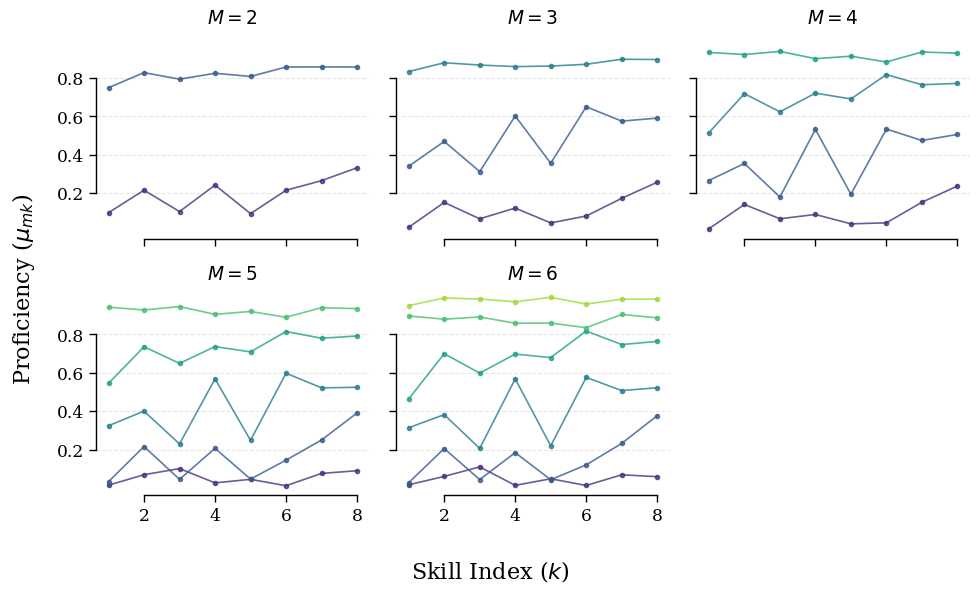

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Use 'seaborn-v0_8-paper' or 'paper' context
sns.set_context("paper", font_scale=1.4)
plt.rcParams['font.family'] = 'serif'

# We'll plot 2, 3, 4, 5, 6 (skipping 1 as it's just the mean)
component_list = [2, 3, 4, 5, 6]
# Use a palette that handles up to 6 distinct lines well
colors = sns.color_palette("viridis", n_colors=6)

fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharey=True, sharex=True)
axes_flat = axes.flatten()

for i, n_comp in enumerate(component_list):
    ax = axes_flat[i]
    
    model = MoLA(Q_matrix=Q_matrix, n_components=n_comp, random_state=42)
    model.fit(X)
    
    # Sort by proficiency to maintain color consistency across subplots
    sorted_idx = np.argsort(model.mu.mean(axis=1))
    
    for rank, k in enumerate(sorted_idx):
        ax.plot(range(1, model.mu.shape[1] + 1), model.mu[k, :], 
                color=colors[rank], marker='o', markersize=3, 
                linewidth=1.2, alpha=0.8, label=f"P{rank+1}")
    
    ax.set_title(f'$M={n_comp}$', fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    sns.despine(ax=ax, trim=True)

# Delete the empty 6th subplot if you only have 5 models
if len(component_list) < len(axes_flat):
    fig.delaxes(axes_flat[-1])

fig.supxlabel("Skill Index ($k$)")
fig.supylabel("Proficiency ($\mu_{mk}$)")
plt.tight_layout()
plt.savefig("figures/mola_evolution.pdf")
plt.show()

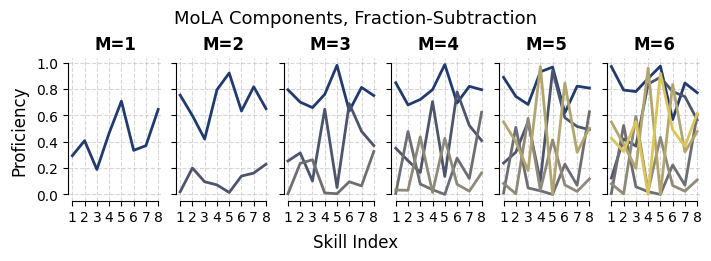

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from aplus.cognitive_model import MoLA

# Number of components to plot
component_list = [1, 2, 3, 4, 5, 6]
n = len(component_list)

# Color palette
colors = sns.color_palette("tab10", n_colors=n)
colors = sns.color_palette("colorblind", n_colors=n)
colors = sns.color_palette("cividis", n_colors=n)

# Create figure with shared y-axis
fig, axes = plt.subplots(1, n, figsize=(7.0, 2.5), constrained_layout=True, sharey=True)

# Loop over different numbers of components
for ax, n_comp in zip(axes, component_list):
    # Model parameters
    model_params = {
        'Q_matrix': Q_matrix,
        'n_components': n_comp,
        'mu_smooth': [2, 2],
        'theta_smooth': [2, 2],
        'pi_smooth': 1,
        'tol': 1e-4,
        'n_iter': 25,
        'use_psuedo_likelihood': False
    }
    
    # Fit model
    model = MoLA(**model_params)
    model.fit(X)
    
    # Plot each component
    for k in range(n_comp):
        ax.plot(model.mu[k, :], color=colors[k], linewidth=2.0) #, label=f'Component {k+1}')
    
    # Short subplot label instead of long title
    ax.set_title(f'M={n_comp}', fontsize=12, weight='bold')
    ax.tick_params(axis='both', labelsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    # ax.legend(fontsize=10, loc='lower right')
    ax.set_xticks(range(model.mu.shape[1]), range(1, model.mu.shape[1]+1))
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

# # Only set y-axis label on first subplot
# axes[1].set_xlabel('Skill Index', fontsize=12)
# axes[0].set_ylabel('Proficiency', fontsize=12)

fig.supxlabel("Skill Index")
fig.supylabel("Proficiency")

# Single figure title
fig.suptitle("MoLA Components, Fraction-Subtraction", fontsize=13)

# Remove top/right spines
sns.despine(trim=True)

# plt.savefig(f"figures/mola-frac-subtr-comps-2.pdf", bbox_inches="tight")
# plt.savefig(f"figures/mola-frac-subtr-comp-2.svg", bbox_inches="tight")
# plt.savefig(f"figures/mola-frac-subtr-comp-2.png", dpi=300, bbox_inches="tight")

plt.show()

In [64]:
model.pi.ravel().shape

(4,)

In [67]:
cov_x = model.get_item_cov()

model.get_skill_score_cov() 

(4, 20, 20)
outer (4, 20, 20)
(4, 20, 20)


matrix([[  7.76888067,  18.21684308,   5.66562414,   3.65472603,
          10.49072749,   2.09941819,  21.56914212,  -1.23111933],
        [ 18.21684308, 118.06373557,  23.54350988,  53.89771155,
          74.47714648,  19.94449411, 185.35808785,  41.01006902],
        [  5.66562414,  23.54350988,   5.52845118,   8.83659712,
          14.44137951,   3.57621797,  34.08003059,   5.07865025],
        [  3.65472603,  53.89771155,   8.83659712,  28.98772491,
          34.94082004,  10.02438915,  91.22893881,  25.82835969],
        [ 10.49072749,  74.47714648,  14.44137951,  34.94082004,
          47.18382125,  12.77882768, 118.34716524,  27.395878  ],
        [  2.09941819,  19.94449411,   3.57621797,  10.02438915,
          12.77882768,   3.56211607,  32.69934249,   8.41876055],
        [ 21.56914212, 185.35808785,  34.08003059,  91.22893881,
         118.34716524,  32.69934249, 300.97966529,  75.10421722],
        [ -1.23111933,  41.01006902,   5.07865025,  25.82835969,
          27.39587

In [39]:
cor_matrix = model.get_proficiency_cov_from_comp(1)
cor_matrix[:5, :5]

array([[0.00054867, 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.00015232, 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.00040535, 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.00043428, 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.00016302]])

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pycirclize import Circos
import seaborn as sns

def plot_chord_diagram(cor_matrix):
 
    # # 1. Your NumPy correlation matrix
    # # (Replacing this with your actual matrix)
    # np.random.seed(42)
    # data = np.random.rand(8, 8)
    # cor_matrix = np.corrcoef(data)

    import textwrap

    def wrap_labels(labels, width=15):
        """
        Takes a list of strings and inserts line breaks at the specified width.
        """
        return [textwrap.fill(label, width=width) for label in labels]

    # 2. Preparation
    # Get attribute names here:
    # https://alexanderrobitzsch.github.io/CDM/reference/fraction.subtraction.qmatrix.html
    labels = [
        "Convert a whole number to a fraction",
        "Separate a whole number from a fraction",
        "Simplify before subtracting",
        "Find a common denominator",
        "Borrow from the whole number part",
        "Column borrow to subtract the second numerator from the first",
        "Subtract numerators",
        "Reduce answers to simplest form"
    ]

    # Apply the function (e.g., break lines every 15-20 characters)
    labels = wrap_labels(labels, width=15)

    M = cor_matrix.copy()
    M[np.tril_indices_from(M)] = 0  # keep upper triangle only  

    # labels = [f"Var {i+1}" for i in range(len(cor_matrix))]
    # Chord diagrams need positive weights for link widths
    # We use absolute values and set a threshold to avoid "hairball" clutter
    threshold = 0.5
    matrix_to_plot = np.where(np.abs(M) > threshold, np.abs(M), 0)

    # Convert to DataFrame (pyCirclize uses this for label mapping)
    matrix_df = pd.DataFrame(matrix_to_plot, index=labels, columns=labels)

    # 3. Create the Chord Diagram
    circos = Circos.chord_diagram(
        matrix_df,
        cmap="viridis",             # Colormap for the outer ring/links
        space=5,                    # Space between sectors
        link_kws=dict(
            ec="black",             # Edge color of links
            lw=0.5,                 # Line weight
            alpha=0.6               # Transparency
        ),
        label_kws=dict(size=12)     # Label font size
    )

    # 4. Display using Matplotlib
    fig = circos.plotfig()
    plt.show()


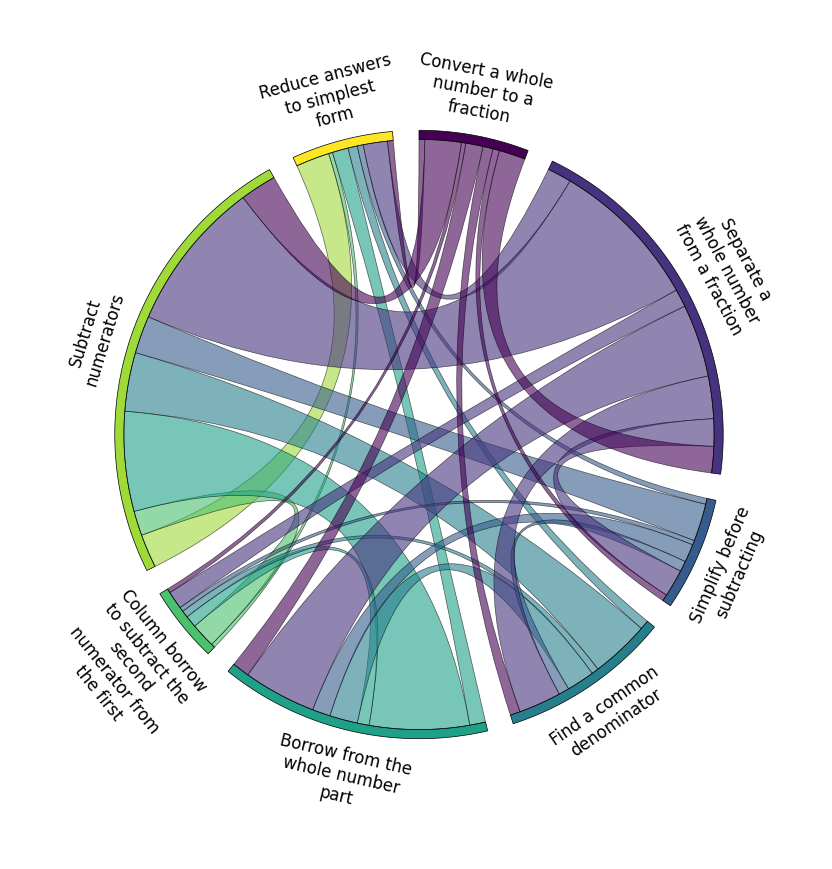

In [90]:
from aplus.cognitive_model import MoLA

model_params = {
    'Q_matrix': Q_matrix,
    'n_components': 2,
    'mu_smooth': [2, 2],
    'theta_smooth': [2, 2],
    'pi_smooth': 1,
    'tol': 1e-4,
    'n_iter': 25,
}

# Fit model
model = MoLA(**model_params)
model.fit(X)

cor_matrix = model.get_skill_score_cov()
plot_chord_diagram(cor_matrix)

Your covariance / correlation matrix is dominated by a single latent factor → correlations ≈ 1

Partial correlations remove the common latent factor, revealing residual dependencies between variables

In psychometrics, this can show skill-specific relationships after accounting for overall ability

All variables move almost perfectly together (first PC)

Partial correlation asks:

“After controlling for all other variables, how much does X_i vary uniquely with X_j?”

In [79]:
X

array([[-1, -1, -1, ...,  1,  1,  1],
       [-1,  1,  1, ...,  1,  1,  1],
       [-1,  1,  1, ..., -1, -1, -1],
       ...,
       [-1, -1, -1, ..., -1, -1, -1],
       [ 1,  1,  1, ...,  1, -1, -1],
       [ 1,  1,  1, ..., -1, -1, -1]], shape=(536, 20), dtype=int32)

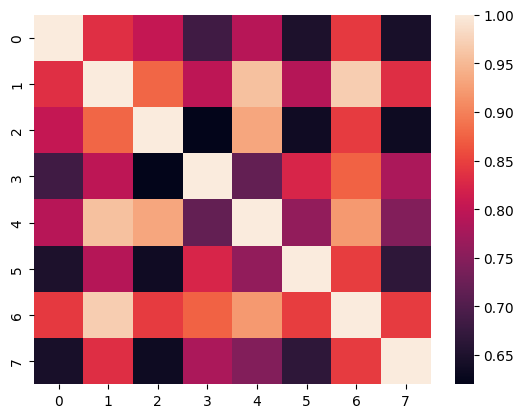

In [73]:
cov = np.cov((X @ Q_matrix).T)
cor = model.convert_cov_to_corr(cov)
sns.heatmap(cor)
plt.show()

In [122]:
(model.pi.T @ model.mu).reshape(-1, 1)

model.mu

array([[0.09792704, 0.21471869, 0.10377635, 0.2411206 , 0.09286745,
        0.2142316 , 0.26450966, 0.33142966],
       [0.74834902, 0.82675123, 0.79250408, 0.82382794, 0.80662828,
        0.85618661, 0.8566023 , 0.8562305 ]])

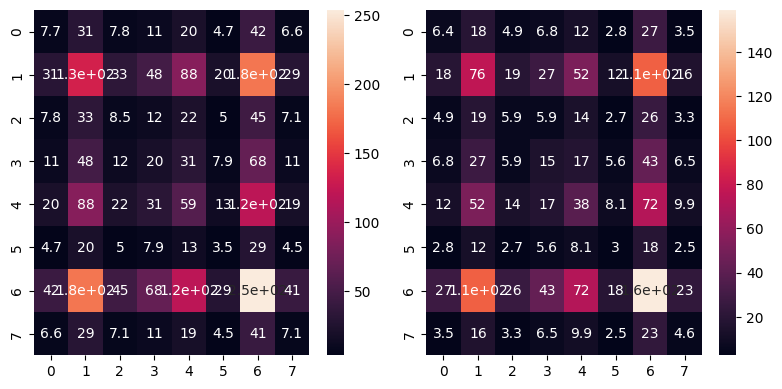

In [86]:
pred_cov = model.get_skill_score_cov()
# cor_matrix_1 = model.get_skill_score_cor(m=1)

# def convert_cov_to_partial_cor(cov):
#     precision = np.linalg.pinv(cov)
#     partial_corr = -precision / np.sqrt(
#         np.outer(np.diag(precision), np.diag(precision))
#     )
#     np.fill_diagonal(partial_corr, 1)

#     return partial_corr

# cor_matrix_0 = convert_cov_to_partial_cor(cor_matrix_0)
# cor_matrix_1 = convert_cov_to_partial_cor(cor_matrix_1)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
sns.heatmap(pred_cov.round(3), ax=ax[0], annot=True)
sns.heatmap(cov.round(3), ax=ax[1], annot=True)
plt.tight_layout()
plt.show()

In [75]:
cov

array([[  6.41645976,  18.44935137,   4.94403683,   6.77263217,
         12.38708328,   2.83364486,  26.94903055,   3.4927326 ],
       [ 18.44935137,  76.16112429,  18.61220533,  27.19379272,
         51.66456967,  11.88785047, 106.68199191,  15.53515135],
       [  4.94403683,  18.61220533,   5.8973776 ,   5.88613475,
         13.99887014,   2.66168224,  25.87909053,   3.29274655],
       [  6.77263217,  27.19379272,   5.88613475,  15.28222904,
         17.34742642,   5.55514019,  43.154917  ,   6.52563816],
       [ 12.38708328,  51.66456967,  13.99887014,  17.34742642,
         38.20905287,   8.09719626,  71.76443019,   9.86108244],
       [  2.83364486,  11.88785047,   2.66168224,   5.55514019,
          8.09719626,   2.97570093,  18.42990654,   2.45981308],
       [ 26.94903055, 106.68199191,  25.87909053,  43.154917  ,
         71.76443019,  18.42990654, 159.09923281,  22.77282745],
       [  3.4927326 ,  15.53515135,   3.29274655,   6.52563816,
          9.86108244,   2.4598130

In [84]:
pred_cov

array([[  7.6744897 ,  30.80979787,   7.75345581,  11.03367643,
         20.37060308,   4.68088754,  42.1936584 ,   6.595631  ],
       [ 30.80979787, 134.20111454,  33.17530959,  48.46220257,
         87.89327887,  20.45979405, 182.20657021,  29.05770362],
       [  7.75345581,  33.17530959,   8.5406264 ,  11.73043793,
         22.25962151,   5.0232482 ,  44.81095216,   7.05195482],
       [ 11.03367643,  48.46220257,  11.73043793,  19.59487908,
         31.27559808,   7.88319195,  68.46242583,  11.12444102],
       [ 20.37060308,  87.89327887,  22.25962151,  31.27559808,
         58.89192772,  13.4062316 , 118.95929798,  18.7999977 ],
       [  4.68088754,  20.45979405,   5.0232482 ,   7.88319195,
         13.4062316 ,   3.51383593,  28.53382713,   4.54562307],
       [ 42.1936584 , 182.20657021,  44.81095216,  68.46242583,
        118.95929798,  28.53382713, 253.66113226,  40.66102225],
       [  6.595631  ,  29.05770362,   7.05195482,  11.12444102,
         18.7999977 ,   4.5456230

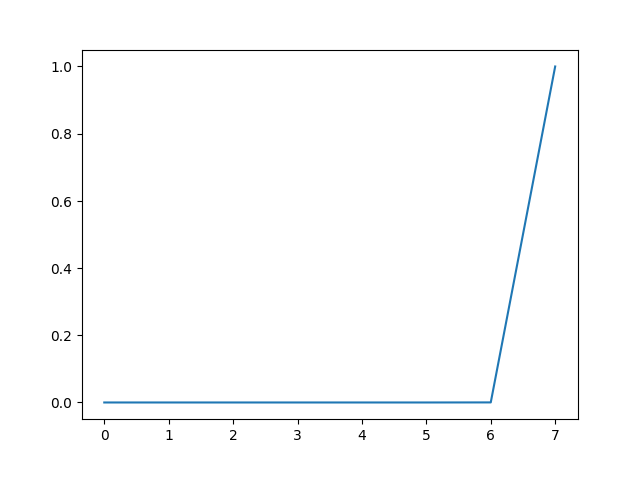

In [69]:
plt.plot([-2.95729336e-17, -7.61066012e-18,  7.05988660e-21,  5.34097813e-19,
  5.16100777e-18,  3.22549587e-17,  1.92514697e-04,  9.99807485e-01])

## Plot Monotonicy

Correct attempt vs total attempt heatmaps for each skill. Check that proficiency always increases left-to-right diagonal and decreases up-to-down vertical.

In [13]:
from aplus.cloud_manager.aws.dynamodb import UserComponentDB

db_manager = UserComponentDB()
post = model.pi
user_id = 'test_user'
model_id = 'test_model'

db_manager.write_to_dynamodb(model_id, user_id, post)

Successfully added record: {'ResponseMetadata': {'RequestId': 'UC6VHNCRB76IIVOKMMEEBLOO53VV4KQNSO5AEMVJF66Q9ASUAAJG', 'HTTPStatusCode': 200, 'HTTPHeaders': {'server': 'Server', 'date': 'Wed, 21 Jan 2026 20:37:21 GMT', 'content-type': 'application/x-amz-json-1.0', 'content-length': '2', 'connection': 'keep-alive', 'x-amzn-requestid': 'UC6VHNCRB76IIVOKMMEEBLOO53VV4KQNSO5AEMVJF66Q9ASUAAJG', 'x-amz-crc32': '2745614147'}, 'RetryAttempts': 0}}


In [9]:
post

array([[0.34716599],
       [0.21267638],
       [0.18951256],
       [0.25064508]])

In [14]:
db_manager.load_from_dynamodb(model_id, user_id)

array([[0.34716599],
       [0.21267638],
       [0.18951256],
       [0.25064508]])

In [15]:
output_dir = f'/tmp/aplus/experimental-data'

import pandas as pd
book_code = 'tfc13'
df = pd.read_csv(f'{output_dir}/{book_code}.csv')
df.head()

,book_title,userId,user_sms_id,user_mastering_id,part_id,isCorrect,attemptTimestamp,attemptNum,assignment_id,course_id,...,chapter_num,chapter_title,section_num,section_title,problem_id,skillId,outcome_title,outcome_code,outcome_type,itemId
0,Microbiology: An Introduction,ffffffff61ef7dfcdbb7bf0a4b6ee2b1,124100905,1936699,23,0,1683426950,1,2535655,1202383,...,18,18. Practical Applications of Immunology,1.0,18.1 Vaccines,1173418,1098743,Contrast nucleic acid vaccines and recombinant...,18.4,local,1173418-23
1,Microbiology: An Introduction,ffffffff5c48df076fbfd73c327ac1c5,100983905,1692703,50,1,1599104333,1,2170675,1159211,...,4,4. Functional Anatomy of Prokaryotic and Eukar...,NaN,NaN,1186309,1098497,"Describe the functions of the nucleus, endopla...",4.19,local,1186309-50
2,Microbiology: An Introduction,ffffffff61ddc9a46fe7854950bd54ff,123490790,1886902,5,1,1668712702,1,2491584,1199599,...,17,17. Adaptive Immunity: Specific Defenses of th...,4.0,17.4 Antigens and Antibodies,1154863,1098725,Name one function for each of the five classes...,17.6,local,1154863-5
3,Microbiology: An Introduction,ffffffff57bdde0de4b05d76bae96e12,80873374,1807912,25,1,1627090144,1,2312732,1188189,...,17,17. Adaptive Immunity: Specific Defenses of th...,6.0,17.6 Results of the AntigenâAntibody Interac...,1154868,1094702,MINAH6: Microbes have unique features that ser...,MINAH6,local,1154868-25
4,Microbiology: An Introduction,ffffffff56b811ede4b0b740dde0cac2,77310897,1559759,1,0,1554227834,1,1901665,1118616,...,8,8. Microbial Genetics,2.0,8.2 The Regulation of Bacterial Gene Expression,1165272,1098562,Explain pre-transcriptional regulation of gene...,8.7,local,1165272-1


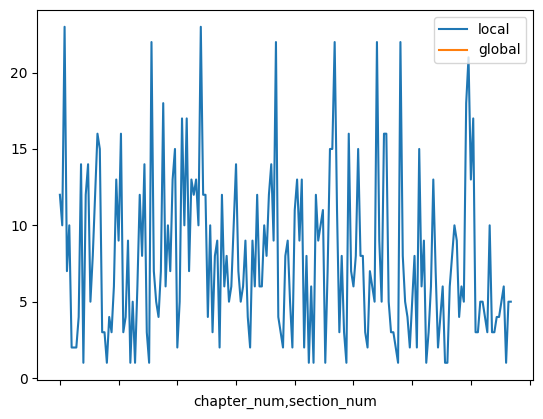

In [16]:
x = df.groupby(['chapter_num', 'section_num', 'outcome_type'])\
    .outcome_code.nunique()\
    .reset_index()\
    .set_index(['chapter_num', 'section_num'])\


x.loc[x.outcome_type == 'local', 'outcome_code'].plot(label='local')
x.loc[x.outcome_type == 'global', 'outcome_code'].plot(label='global')
# x.loc[:, 'outcome_code'].plot(label='total')

plt.legend()
plt.show()